# Project 1 Template

This notebook will be used to house all the code, comments, and analysis needed to complete out first group project.

**Final code submission will be an HTML file**

## Overview

### Situation:
Suppose we work for United Airlines (carrier code UA). To improve both efficiency and customer satisfaction we have been asked to analyze departure delays for NYC flights.

Based off of our findings, we will prepare a report that utilizes the exploratory data analysis methods and permutation tests to analyze variables that affect departure delays.


### Task:
Prepare a report that utilizes the exploratory data analysis methods that we have been studying, and permutation tests, to analyze departure delays.

This report should be written for a general audience, not a technical one. This means that you should be clearly explaining everything without assuming that the audience has any specialized knowledge. It also means that you should use clear words and phrases, rather than variable names, when labeling and discussing your plots and other r

## Domain Problem

### Purpose:
**We aim to analyze the relationship between departure delay times and each of the following variables:**

* Time of day
* Time of year
* Temperature
* Wind speed
* Precipitation
* Visibility

### Domain Problem:
Which of the 6 variables has the biggest effect on departure delay times for United Airlines?

## Analytic Approach

## Import Libraries & Loading the data
Assignees: Edwin

### Datasets

**We will be using the following datasets:**

* **Weather**
  * From the `nycflights13` package, this data set includes values from the variables we are going to analyze further. Like the departure airport, time of day, time of year, visibility, precipitation level, and wind speed.

* **Airlines**
  * From the `nycflights13` package - this data set includes details about each airline, including the carrier airline code and airline name.

* **Airports**
  * From the `nycflights13` package - this data set includes details about each airport, like the faa code, name, altitude, latitude/longitude, altitude(ft), timezone, and daylight-saving indicators.

* **Flights**
  * From the `nycflights13` package, this data set includes...


**Note:** These data sets are seperate entities so need to merge the flight and weather data together.

### Load in Libraries and Packages
**Assignee:** Edwin

In [ ]:
# Install these packages if needed
install.packages(c("nycflights13", "ggplot2", "dplyr", "tidyr", "tibble", "forcats", "lubridate"))


Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
# Loading required libraries

library(nycflights13) #data set
library(ggplot2)#for data visualization
library(dplyr) #used for data manipulation in R - has functions - filter, select, muttate, arrange,summarize
library(tidyr) #for tidying and rehsaping data
library(tibble) #modern dataframes for R
library(forcats)#used for categorical/factor data manipulation
library(lubridate) #used to work with date and time


Attaching package: ‘lubridate’


The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union




### Check that each dataset imported correctly

In [ ]:
head(weather)

origin,year,month,day,hour,temp,dewp,humid,wind_dir,wind_speed,wind_gust,precip,pressure,visib,time_hour
<chr>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dttm>
EWR,2013,1,1,1,39.02,26.06,59.37,270,10.35702,NA,0,1012.0,10,2013-01-01 01:00:00
EWR,2013,1,1,2,39.02,26.96,61.63,250,8.05546,NA,0,1012.3,10,2013-01-01 02:00:00
EWR,2013,1,1,3,39.02,28.04,64.43,240,11.50780,NA,0,1012.5,10,2013-01-01 03:00:00
EWR,2013,1,1,4,39.92,28.04,62.21,250,12.65858,NA,0,1012.2,10,2013-01-01 04:00:00
EWR,2013,1,1,5,39.02,28.04,64.43,260,12.65858,NA,0,1011.9,10,2013-01-01 05:00:00
EWR,2013,1,1,6,37.94,28.04,67.21,240,11.50780,NA,0,1012.4,10,2013-01-01 06:00:00


In [ ]:
head(airlines)

carrier,name
<chr>,<chr>
9E,Endeavor Air Inc.
AA,American Airlines Inc.
AS,Alaska Airlines Inc.
B6,JetBlue Airways
DL,Delta Air Lines Inc.
EV,ExpressJet Airlines Inc.


In [ ]:
head(airports)

faa,name,lat,lon,alt,tz,dst,tzone
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
04G,Lansdowne Airport,41.13047,-80.61958,1044,-5,A,America/New_York
06A,Moton Field Municipal Airport,32.46057,-85.68003,264,-6,A,America/Chicago
06C,Schaumburg Regional,41.98934,-88.10124,801,-6,A,America/Chicago
06N,Randall Airport,41.43191,-74.39156,523,-5,A,America/New_York
09J,Jekyll Island Airport,31.07447,-81.42778,11,-5,A,America/New_York
0A9,Elizabethton Municipal Airport,36.37122,-82.17342,1593,-5,A,America/New_York


In [ ]:
head(flights)


year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<int>,<dbl>,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dttm>
2013,1,1,517,515,2,830,819,11,UA,1545,N14228,EWR,IAH,227,1400,5,15,2013-01-01 05:00:00
2013,1,1,533,529,4,850,830,20,UA,1714,N24211,LGA,IAH,227,1416,5,29,2013-01-01 05:00:00
2013,1,1,542,540,2,923,850,33,AA,1141,N619AA,JFK,MIA,160,1089,5,40,2013-01-01 05:00:00
2013,1,1,544,545,-1,1004,1022,-18,B6,725,N804JB,JFK,BQN,183,1576,5,45,2013-01-01 05:00:00
2013,1,1,554,600,-6,812,837,-25,DL,461,N668DN,LGA,ATL,116,762,6,0,2013-01-01 06:00:00
2013,1,1,554,558,-4,740,728,12,UA,1696,N39463,EWR,ORD,150,719,5,58,2013-01-01 05:00:00


## Initial Exploration of the Data
**Assignee:** Alyssa

Instead of working through each attribute for the dataset, I will create a function that ouputs all the information we want for each dataset.

This will be called `describe_dataset()`

In [ ]:
# Define a reusable dataset summary function
describe_dataset <- function(data) {
  cat("📘 DATASET SUMMARY\n")
  cat("----------------------------\n")

  # Dataset class and type
  cat("Class: ", class(data), "\n")

  # Dimensions
  cat("Rows: ", nrow(data), "\n")
  cat("Columns: ", ncol(data), "\n\n")

  # Memory size
  cat("Memory Size: ", format(object.size(data), units = "MB"), "\n\n")

  # Column names
  cat("Column Names:\n")
  print(colnames(data))
  cat("\n")

  # Data types of columns
  cat("Column Classes:\n")
  print(sapply(data, class))
  cat("\n")

  # Preview first few rows
  cat("Data Preview (first 5 rows):\n")
  print(head(data, 5))

  cat("\n✅ Summary complete.\n")
}

### Analyse Each Dataset as they are now

#### Weather

##### `desribe_dataset()`

Use the function created above to describe the `weather` dataset

In [ ]:
describe_dataset(weather)

📘 DATASET SUMMARY
----------------------------
Class:  tbl_df tbl data.frame 
Rows:  26115 
Columns:  15 

Memory Size:  2.6 Mb 

Column Names:
 [1] "origin"     "year"       "month"      "day"        "hour"      
 [6] "temp"       "dewp"       "humid"      "wind_dir"   "wind_speed"
[11] "wind_gust"  "precip"     "pressure"   "visib"      "time_hour" 

Column Classes:
$origin
[1] "character"

$year
[1] "integer"

$month
[1] "integer"

$day
[1] "integer"

$hour
[1] "integer"

$temp
[1] "numeric"

$dewp
[1] "numeric"

$humid
[1] "numeric"

$wind_dir
[1] "numeric"

$wind_speed
[1] "numeric"

$wind_gust
[1] "numeric"

$precip
[1] "numeric"

$pressure
[1] "numeric"

$visib
[1] "numeric"

$time_hour
[1] "POSIXct" "POSIXt" 


Data Preview (first 5 rows):
# A tibble: 5 × 15
  origin  year month   day  hour  temp  dewp humid wind_dir wind_speed wind_gust
  <chr>  <int> <int> <int> <int> <dbl> <dbl> <dbl>    <dbl>      <dbl>     <dbl>
1 EWR     2013     1     1     1  39.0  26.1  59.4      270  

##### Column Details
For the ones we will use

In [ ]:
weather$origin

[1] "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR"
   [13] "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR"
   [25] "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR"
   [37] "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR"
   [49] "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR"
   [61] "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR"
   [73] "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR"
   [85] "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR"
   [97] "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR"
  [109] "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR"
  [121] "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR"
  [133] "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR"
  [145] "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR"
  [157] "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR"
  [169] "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR"
  [181] "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR"
  [193] "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR"
  [205] "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR"
  [217] "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR"
  [229] "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR"
  [241] "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR"
  [253] "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR"
  [265] "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR"
  [277] "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR"
  [289] "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR"
  [301] "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR"
  [313] "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR"
  [325] "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR"
  [337] "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR"
  [349] "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR"
  [361] "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR"
  [373] "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR"
  [385] "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR"
  [397] "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR"
  [409] "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR"
  [421] "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR"
  [433] "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR"
  [445] "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR"
  [457] "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR"
  [469] "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR"
  [481] "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR"
  [493] "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR"
  [505] "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR"
  [517] "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR"
  [529] "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR"
  [541] "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR"
  [553] "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR"
  [565] "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR"
  [577] "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR"
  [589] "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR" "EWR"
  [6

In [ ]:
summary(weather$year)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   2013    2013    2013    2013    2013    2013 

In [ ]:
summary(weather$month)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  1.000   4.000   7.000   6.504   9.000  12.000 

In [ ]:
summary(weather$day)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   1.00    8.00   16.00   15.68   23.00   31.00 

In [ ]:
summary(weather$hour)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   0.00    6.00   11.00   11.49   17.00   23.00 

In [ ]:
# hour vs time_hour
summary(weather$time_hour)

                 Min.               1st Qu.                Median 
"2013-01-01 01:00:00" "2013-04-01 21:30:00" "2013-07-01 14:00:00" 
                 Mean               3rd Qu.                  Max. 
"2013-07-01 18:26:37" "2013-09-30 13:00:00" "2013-12-30 18:00:00" 

In [ ]:
summary(weather$temp)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.    NA's 
  10.94   39.92   55.40   55.26   69.98  100.04       1 

In [ ]:
summary(weather$wind_speed)

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max.     NA's 
   0.000    6.905   10.357   10.517   13.809 1048.361        4 

In [ ]:
summary(weather$precip)

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
0.000000 0.000000 0.000000 0.004469 0.000000 1.210000 

In [ ]:
summary(weather$visib)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  0.000  10.000  10.000   9.255  10.000  10.000 

<br>

**Description of each column we need:**

- `origin`
  - datatype: character
  - Displays where each flight departed from
  
- `year`
  - datatype: integer
  - Displays the year in which the data represents, which is 2013!

- `month`
  - datatype: integer
  - Displays the month by number from 1-12

- `day`
  - datatype: integer
  - Displays the day of the month from 1-30

- `hour`
  - datatype: integer
  - Displays the hour of the day from 0-23

- `temp`
  - datatype: numeric
  - Displays the temperature from 10.94-100.04
  - Has 1 missing value

- `wind_speed`
  - datatype: numeric
  - Displays the wind speed from 0-1048.361 MPH
  - Has 4 missing values

- `precip`
  - datatype: numeric
  - Displays precipitation levels

- `visib`
  - datatype: numeric
  - Displays visibility levels from 1-10



##### Summary

Based off of the output above, we can observe the following for this dataset:

- Is a `tibble` format, meaning it is part of the tidyverse.
- Has a memory size of 2.6 Mb
- Consists of **15 columns** and **26115 entries/rows**
- The columns we need for our anlysis are:
  - `origin`(char) displays the 3-letter FAA code for the airport of departure
  - `year` (int) displays the year of 2013
  - `month` (int) displays the month from 1-12
  - `day` (int) displays the day of the month from 1-30
  - `hour` (into) displays the hour of day from 0-23
  - `temp` (num) displays the temperature in Farenheit
  - `wind_speed` (num) displays wind speed in mph
  - `precip` (num) displays precipitation levels
  - `visib` (num) displays visibility rating
  - `time_hour` displays the combination of date + time

- Some changes we may want to make to this dataset
  - Change the names to display better readability
  - Label subsets of variables:
    - `hour` into Morning, Afternoon, and Evening
    - `month` into Jan, Feb.. Dec

- There are **missing values** in the following variables:
  - `temp`, has 1 missing value.
  - `wind_speed`, has 4 missing values



#### Airlines

##### `describe_dataset()`

In [ ]:
describe_dataset(airlines)

📘 DATASET SUMMARY
----------------------------
Class:  tbl_df tbl data.frame 
Rows:  16 
Columns:  2 

Memory Size:  0 Mb 

Column Names:
[1] "carrier" "name"   

Column Classes:
    carrier        name 
"character" "character" 

Data Preview (first 5 rows):
# A tibble: 5 × 2
  carrier name                  
  <chr>   <chr>                 
1 9E      Endeavor Air Inc.     
2 AA      American Airlines Inc.
3 AS      Alaska Airlines Inc.  
4 B6      JetBlue Airways       
5 DL      Delta Air Lines Inc.  

✅ Summary complete.


##### Column Details

In [ ]:
summary(airlines$carrier)

   Length     Class      Mode 
       16 character character 

In [ ]:
summary(airlines$name)

   Length     Class      Mode 
       16 character character 

In [ ]:
airlines

carrier,name
<chr>,<chr>
9E,Endeavor Air Inc.
AA,American Airlines Inc.
AS,Alaska Airlines Inc.
B6,JetBlue Airways
DL,Delta Air Lines Inc.
EV,ExpressJet Airlines Inc.
F9,Frontier Airlines Inc.
FL,AirTran Airways Corporation
HA,Hawaiian Airlines Inc.


##### Summary

Based off of the output above, we can observe the following for this dataset:

- Is a `tibble` format, meaning it is part of the tidyverse.
- Has a memory size of 0 Mb
- Consists of **2 columns** and **16 entries/rows**

- The columns we need for our anlysis are (all):
  - `carrier` (char) displays the airline code
  - `name` (char) displays the airline name


- There are no missing values in this dataset


#### Airports

##### `describe_dataset()`

In [ ]:
describe_dataset(airports)

📘 DATASET SUMMARY
----------------------------
Class:  tbl_df tbl data.frame 
Rows:  1458 
Columns:  8 

Memory Size:  0.3 Mb 

Column Names:
[1] "faa"   "name"  "lat"   "lon"   "alt"   "tz"    "dst"   "tzone"

Column Classes:
        faa        name         lat         lon         alt          tz 
"character" "character"   "numeric"   "numeric"   "numeric"   "numeric" 
        dst       tzone 
"character" "character" 

Data Preview (first 5 rows):
# A tibble: 5 × 8
  faa   name                            lat   lon   alt    tz dst   tzone       
  <chr> <chr>                         <dbl> <dbl> <dbl> <dbl> <chr> <chr>       
1 04G   Lansdowne Airport              41.1 -80.6  1044    -5 A     America/New…
2 06A   Moton Field Municipal Airport  32.5 -85.7   264    -6 A     America/Chi…
3 06C   Schaumburg Regional            42.0 -88.1   801    -6 A     America/Chi…
4 06N   Randall Airport                41.4 -74.4   523    -5 A     America/New…
5 09J   Jekyll Island Airport          31.1

##### Column Details

In [ ]:
head(airports)

faa,name,lat,lon,alt,tz,dst,tzone
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
04G,Lansdowne Airport,41.13047,-80.61958,1044,-5,A,America/New_York
06A,Moton Field Municipal Airport,32.46057,-85.68003,264,-6,A,America/Chicago
06C,Schaumburg Regional,41.98934,-88.10124,801,-6,A,America/Chicago
06N,Randall Airport,41.43191,-74.39156,523,-5,A,America/New_York
09J,Jekyll Island Airport,31.07447,-81.42778,11,-5,A,America/New_York
0A9,Elizabethton Municipal Airport,36.37122,-82.17342,1593,-5,A,America/New_York


In [ ]:
airports$faa

[1] "04G" "06A" "06C" "06N" "09J" "0A9" "0G6" "0G7" "0P2" "0S9" "0W3" "10C"
  [13] "17G" "19A" "1A3" "1B9" "1C9" "1CS" "1G3" "1G4" "1H2" "1OH" "1RL" "23M"
  [25] "24C" "24J" "25D" "29D" "2A0" "2B2" "2G2" "2G9" "2H0" "2J9" "369" "36U"
  [37] "38W" "3D2" "3G3" "3G4" "3J1" "3W2" "40J" "41N" "47A" "49A" "49X" "4A4"
  [49] "4A7" "4A9" "4B8" "4G0" "4G2" "4G4" "4I7" "4U9" "52A" "54J" "55J" "55S"
  [61] "57C" "5B2" "60J" "6A2" "6J4" "6K8" "6S0" "6S2" "6Y8" "70J" "70N" "7A4"
  [73] "7D9" "7N7" "8M8" "93C" "99N" "9A1" "9A5" "9G1" "A39" "A50" "AAF" "AAP"
  [85] "ABE" "ABI" "ABL" "ABQ" "ABR" "ABY" "ACJ" "ACK" "ACT" "ACV" "ACY" "ADK"
  [97] "ADM" "ADQ" "ADS" "ADW" "AET" "AEX" "AFE" "AFW" "AGC" "AGN" "AGS" "AHN"
 [109] "AIA" "AIK" "AIN" "AIZ" "AKB" "AKC" "AKI" "AKK" "AKN" "AKP" "ALB" "ALI"
 [121] "ALM" "ALO" "ALS" "ALW" "ALX" "ALZ" "AMA" "ANB" "ANC" "AND" "ANI" "ANN"
 [133] "ANP" "ANQ" "ANV" "AOH" "AOO" "AOS" "APA" "APC" "APF" "APG" "APN" "AQC"
 [145] "ARA" "ARB" "ARC" "ART" "ARV" "ASE" "ASH" "AST" "ATK" "ATL" "ATT" "ATW"
 [157] "ATY" "AUG" "AUK" "AUO" "AUS" "AUW" "AVL" "AVO" "AVP" "AVW" "AVX" "AZA"
 [169] "AZO" "BAB" "BAD" "BAF" "BBX" "BCE" "BCT" "BDE" "BDL" "BDR" "BEC" "BED"
 [181] "BEH" "BET" "BFD" "BFF" "BFI" "BFL" "BFM" "BFP" "BFT" "BGE" "BGM" "BGR"
 [193] "BHB" "BHM" "BID" "BIF" "BIG" "BIL" "BIS" "BIV" "BIX" "BJC" "BJI" "BKC"
 [205] "BKD" "BKF" "BKG" "BKH" "BKL" "BKW" "BKX" "BLD" "BLF" "BLH" "BLI" "BLV"
 [217] "BMC" "BMG" "BMI" "BMT" "BMX" "BNA" "BOI" "BOS" "BOW" "BPT" "BQK" "BRD"
 [229] "BRL" "BRO" "BRW" "BSF" "BTI" "BTM" "BTR" "BTT" "BTV" "BUF" "BUR" "BUU"
 [241] "BUY" "BVY" "BWD" "BWG" "BWI" "BXK" "BXS" "BYH" "BYS" "BYW" "BZN" "C02"
 [253] "C16" "C47" "C65" "C89" "C91" "CAE" "CAK" "CAR" "CBE" "CBM" "CCO" "CCR"
 [265] "CDB" "CDC" "CDI" "CDK" "CDN" "CDR" "CDS" "CDV" "CDW" "CEC" "CEF" "CEM"
 [277] "CEU" "CEW" "CEZ" "CFD" "CGA" "CGC" "CGF" "CGI" "CGX" "CGZ" "CHA" "CHI"
 [289] "CHO" "CHS" "CHU" "CIC" "CID" "CIK" "CIL" "CIU" "CKB" "CKD" "CKF" "CKV"
 [301] "CLC" "CLD" "CLE" "CLL" "CLM" "CLS" "CLT" "CLW" "CMH" "CMI" "CMX" "CNM"
 [313] "CNW" "CNY" "COD" "COE" "COF" "COI" "CON" "COS" "COT" "COU" "CPR" "CPS"
 [325] "CRE" "CRP" "CRW" "CSG" "CTB" "CTH" "CTJ" "CTY" "CVG" "CVN" "CVO" "CVS"
 [337] "CVX" "CWA" "CWI" "CWT" "CXF" "CXL" "CXO" "CXY" "CYF" "CYM" "CYS" "CYT"
 [349] "CZF" "CZG" "CZN" "DAB" "DAL" "DAW" "DAY" "DBN" "DBQ" "DCA" "DDC" "DEC"
 [361] "DEN" "DET" "DFW" "DGL" "DHB" "DHN" "DHT" "DIK" "DKB" "DKK" "DKX" "DLF"
 [373] "DLG" "DLH" "DLL" "DMA" "DNL" "DNN" "DNV" "DOV" "DPA" "DQH" "DRG" "DRI"
 [385] "DRM" "DRO" "DRT" "DSM" "DTA" "DTS" "DTW" "DUC" "DUG" "DUJ" "DUT" "DVL"
 [397] "DVT" "DWA" "DWH" "DWS" "DXR" "DYS" "E25" "E51" "E55" "E63" "E91" "EAA"
 [409] "EAR" "EAT" "EAU" "ECA" "ECG" "ECP" "EDF" "EDW" "EEK" "EEN" "EET" "EFD"
 [421] "EGA" "EGE" "EGT" "EGV" "EGX" "EHM" "EIL" "EKI" "EKN" "EKO" "EKY" "ELD"
 [433] "ELI" "ELM" "ELP" "ELV" "ELY" "EMK" "EMP" "ENA" "END" "ENV" "ENW" "EOK"
 [445] "EPM" "EQY" "ERI" "ERV" "ERY" "ESC" "ESD" "ESF" "ESN" "EUF" "EUG" "EVV"
 [457] "EVW" "EWB" "EWK" "EWN" "EWR" "EXI" "EYW" "F57" "FAF" "FAI" "FAR" "FAT"
 [469] "FAY" "FBG" "FBK" "FBR" "FBS" "FCA" "FCM" "FCS" "FDW" "FDY" "FFA" "FFC"
 [481] "FFO" "FFT" "FFZ" "FHU" "FIT" "FKL" "FLD" "FLG" "FLL" "FLO" "FLV" "FME"
 [493] "FMH" "FMN" "FMY" "FNL" "FNR" "FNT" "FOD" "FOE" "FOK" "FRD" "FRI" "FRN"
 [505] "FRP" "FSD" "FSI" "FSM" "FST" "FTK" "FTW" "FTY" "FUL" "FWA" "FXE" "FYU"
 [517] "FYV" "FZG" "FZI" "GAD" "GAI" "GAL" "GAM" "GBN" "GCC" "GCK" "GCN" "GCW"
 [529] "GDV" "GDW" "GED" "GEG" "GEU" "GFK" "GFL" "GGE" "GGG" "GGW" "GHG" "GIF"
 [541] "GJT" "GKN" "GKY" "GLD" "GLH" "GLS" "GLV" "GNT" "GNU" "GNV" "GON" "GPT"
 [553] "GPZ" "GQQ" "GRB" "GRF" "GRI" "GRK" "GRM" "GRR" "GSB" "GSO" "GSP" "GST"
 [565] "GTB" "GTF" "GTR" "GTU" "GUC" "GUP" "GUS" "GVL" "GVQ" "GVT" "GWO" "GYY"
 [577] "HBG" "HBR" "HCC" "HCR" "HDH" "HDI" "HDN" "HDO" "HFD" "HGR" "HHH" "HHI"
 [589] "HHR" "HIB" "HIF" "HII" "HIO" "HKB" "HKY" "HLG" "HLN" "HLR" "HMN" "HNH"
 [601] "HNL" "HNM" "HNS" "HOB" "HOM" "HON" "HOP" "HOT

In [ ]:
airports$tz

[1]  -5  -6  -6  -5  -5  -5  -5  -5  -5  -8  -5  -6  -5  -5  -5  -5  -8  -6
  [19]  -5  -7  -6  -5  -8  -6  -5  -5  -6  -5  -5  -5  -5  -5  -6  -5  -9  -7
  [37]  -8  -6  -5  -5  -5  -5  -5  -5  -5  -5  -8  -5  -5  -6  -5  -5  -5  -5
  [55]  -5  -7  -5  -6  -5  -8  -6  -5  -5  -5  -5  -9  -7  -8  -5  -5  -5  -6
  [73]  -5  -5  -5  -6  -5  -5  -5  -5  -7  -7  -5  -6  -5  -6  -9  -7  -6  -5
  [91]  -5  -5  -6  -8  -5  -9  -6  -9  -6  -5  -9  -6  -9  -6  -5  -9  -5  -5
 [109]  -7  -5  -9  -6  -9  -5  -9  -9  -9  -9  -5  -6  -7  -6  -7  -8  -5  -9
 [127]  -6  -6  -9  -5  -9  -9  -5  -5  -9  -5  -5  -9  -7  -8  -5  -5  -5  -9
 [145]  -6  -5  -9  -5  -6  -7  -5  -8  -9  -5  -6  -6  -6  -5  -9  -6  -6  -6
 [163]  -5  -5  -5  -7  -8  -7  -5  -8  -6  -5  -5  -7  -5  -6  -5  -5  -6  -5
 [181]  -5  -9  -5  -7  -8  -8  -6  -5  -5  -5  -5  -5  -5  -6  -5  -7  -9  -7
 [199]  -6  -5  -6  -7  -6  -9  -6  -7  -6 -10  -5  -5  -6  -7  -5  -8  -8  -6
 [217]  -7  -5  -6  -6  -9  -6  -7  -5  -5  -6  -5  -6  -6  -6  -9 -10  -9  -7
 [235]  -6  -9  -5  -5  -8  -6  -5  -5  -6  -6  -5  -7  -8  -6  -8  -8  -7  -6
 [253]  -6  -6  -5  -6  -5  -5  -5  -5  -5  -6  -5  -8  -9  -7  -5  -5  -5  -7
 [271]  -6  -9  -5  -8  -5  -9  -5  -6  -7  -6  -9  -5  -5  -6  -6  -7  -5  -6
 [289]  -5  -5  -9  -8  -6  -9  -9  -5  -5  -9  -5  -6  -6  -8  -5  -6  -8  -8
 [307]  -5  -5  -5  -6  -5  -7  -6  -7  -7  -8  -5  -5  -5  -7  -6  -6  -7  -6
 [325]  -5  -6  -5  -5  -7  -5  -5  -5  -5  -7  -8  -7  -5  -6  -6  -8  -9  -8
 [343]  -6  -5  -9  -9  -7  -9  -9  -5  -9  -5  -6  -5  -5  -5  -6  -5  -6  -6
 [361]  -7  -5  -6  -7  -8  -6  -6  -7  -6  -5  -5  -6  -9  -6  -6  -7  -5  -5
 [379]  -6  -5  -6  -5  -9  -6  -5  -7  -6  -6  -7  -6  -5  -6  -7  -5  -9  -6
 [397]   8  -8  -6  -5  -5  -6  -7  -7  -8  -7  -7  -9  -6  -8  -6  -5  -5  -6
 [415]  -9  -8  -9  -5  -6  -6  -7  -7  -6  -6  -9  -9  -9  -5  -5  -8  -6  -6
 [433]  -9  -5  -7  -9  -8  -9  -6  -9  -6  -7  -6  -6  -5  -5  -5  -6  -5  -5
 [451]  -8  -6  -5  -6  -8  -6  -7  -5  -6  -5  -5  -9  -5  -5  -5  -9  -6  -8
 [469]  -5  -5  -9  -7  -8  -7  -6  -7  -5  -5  -5  -5  -5  -5  -7  -7  -5  -5
 [487]  -6  -7  -5  -5  -6  -5  -5  -7  -5  -7  -9  -5  -6  -6  -5  -8  -6  -9
 [505]  -5  -6  -6  -6  -6  -5  -6  -5  -8  -5  -5  -9  -6  -5  -5  -6  -5  -9
 [523]  -9  -6  -7  -6  -7  -7  -7  -5  -5  -8  -7  -6  -5  -5  -6  -7  -5  -5
 [541]  -7  -9  -6  -7  -6  -6  -9  -7  -9  -5  -5  -6  -6  -5  -6  -8  -6  -6
 [559]  -6  -5  -5  -5  -5  -9  -5  -7  -6  -6  -7  -7  -5  -5  -5  -6  -6  -6
 [577]  -6  -6  -5  -9 -10  -5  -7  -6  -5  -5  -5 -10  -8  -6  -7  -7  -8  -9
 [595]  -5  -5  -7  -6  -7  -9 -10 -10  -9  -7  -9  -6  -6  -6  -6  -9  -5  -8
 [613]  -5  -6  -6  -6  -8  -9  -5  -6  -5  -5  -6  -5  -5  -9  -6  -5  -7  -8
 [631]  -5  -5  -5  -9  -9  -6  -5  -6  -5  -5  -6  -9  -6  -9  -7  -5  -7  -9
 [649]  -7  -6  -5  -6  -9  -7  -6  -5  -9  -5  -5  -5  -6  -5  -6  -6  -6  -8
 [667]  -5  -7  -6  -8  -5  -9  -6  -5  -6  -5  -5  -6  -5 -10  -6  -6  -8  -5
 [685]  -7  -6  -5  -6  -6  -6  -5  -5  -7 -10  -5  -6  -6  -6  -9  -6  -5  -5
 [703]  -5  -6  -5  -5  -5  -5  -9  -5  -6  -9  -9  -9  -9  -9  -9  -9  -8  -9
 [721]  -9  -9  -9  -9  -9  -9  -9  -9  -9  -8  -9  -9  -9  -9 -10  -9  -9  -9
 [739]  -9  -9  -9  -9  -9  -9  -9  -9  -9  -9  -9  -9  -9  -9  -9  -9  -9  -9
 [757]  -9  -9  -9  -8  -8  -8  -7  -5  -5  -7  -5  -7  -8  -6  -8  -6  -5  -6
 [775]  -6  -5  -6  -5  -5  -5  -5  -5  -5  -5  -6  -6  -5  -8  -5  -7  -9  -8
 [793]  -5  -7 -10  -6  -9  -8  -9  -5  -8  -5  -6  -5  -6  -5 -10  -6  -5  -5
 [811]  -8  -5  -8  -6  -6  -5  -7  -6  -5  -8  -6  -7  -5 -10  -9  -8  -7  -7
 [829]  -5  -5  -6  -5  -8  -7  -6  -5  -6  -5  -8  -8  -6  -5  -5  -8  -5  -8
 [847]  -5  -9  -6  -6  -9  -5  -5  -6  -5  -6  -5  -6  -6  -8  -5  -6  -6  -8
 [865]  -6  -5  -5  -6  -5  -5  -5  -6  -9  -8  -5  -8  -5  -6  -6  -5  -5  -6
 [883]  -6  -5 -10  -6  -6  -5  -6  -7  -6  -5  -9  -7  -5  -6  -9  -8  -5  -5
 [901]  -8  -6  -9  -5  -6  -8  -6  -9  -5  -8  -5  -

In [ ]:
airports$dst

[1] "A" "A" "A" "A" "A" "A" "A" "A" "U" "A" "A" "U" "A" "U" "A" "A" "A" "U"
  [19] "A" "A" "A" "U" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A"
  [37] "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A"
  [55] "U" "A" "A" "A" "A" "A" "A" "A" "U" "A" "A" "A" "A" "A" "A" "A" "A" "A"
  [73] "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A"
  [91] "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A"
 [109] "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A"
 [127] "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A"
 [145] "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "U"
 [163] "A" "A" "A" "U" "A" "N" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A"
 [181] "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A"
 [199] "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "U" "A" "A" "A" "A"
 [217] "A" "A" "A" "A" "A" "A" "A" "A" "U" "A" "A" "U" "A" "A" "A" "A" "A" "A"
 [235] "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "U" "A" "A" "A" "A" "A" "U"
 [253] "A" "U" "A" "A" "U" "A" "A" "A" "A" "A" "A" "A" "A" "A" "U" "A" "A" "A"
 [271] "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "U" "A" "A"
 [289] "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A"
 [307] "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "U"
 [325] "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A"
 [343] "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A"
 [361] "A" "A" "A" "N" "A" "A" "A" "A" "U" "A" "A" "A" "A" "A" "A" "A" "A" "A"
 [379] "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A"
 [397] "A" "A" "A" "A" "A" "A" "A" "A" "A" "U" "N" "A" "A" "A" "A" "A" "A" "A"
 [415] "A" "A" "A" "A" "A" "A" "U" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A"
 [433] "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A"
 [451] "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A"
 [469] "A" "A" "A" "A" "A" "A" "A" "A" "A" "U" "A" "A" "A" "A" "A" "A" "A" "A"
 [487] "A" "N" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A"
 [505] "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A"
 [523] "A" "A" "A" "A" "N" "U" "A" "A" "A" "A" "N" "A" "A" "A" "A" "A" "A" "A"
 [541] "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A"
 [559] "U" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A"
 [577] "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "U" "A" "A" "A" "A" "N" "A" "A"
 [595] "A" "A" "A" "A" "A" "A" "N" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A"
 [613] "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A"
 [631] "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A"
 [649] "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "U" "A" "A" "A" "A" "A" "A" "A"
 [667] "A" "N" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "N" "U" "A" "A" "A"
 [685] "A" "A" "A" "A" "A" "A" "A" "A" "A" "N" "A" "A" "A" "A" "A" "A" "A" "A"
 [703] "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A"
 [721] "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "N" "A" "A" "A"
 [739] "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A"
 [757] "A" "A" "A" "A" "A" "U" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A"
 [775] "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A"
 [793] "A" "A" "N" "A" "A" "A" "U" "A" "A" "A" "A" "A" "A" "A" "N" "A" "A" "A"
 [811] "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A"
 [829] "A" "U" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "U" "A"
 [847] "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A"
 [865] "A" "A" "A" "A" "A" "A" "U" "A" "A" "A" "A" "A" "A" "A" "A" "U" "A" "A"
 [883] "A" "A" "N" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "N" "A"
 [901] "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "U

In [ ]:
airports$tzone

[1] "America/New_York"    "America/Chicago"     "America/Chicago"    
   [4] "America/New_York"    "America/New_York"    "America/New_York"   
   [7] "America/New_York"    "America/New_York"    "America/New_York"   
  [10] "America/Los_Angeles" "America/New_York"    "America/Chicago"    
  [13] "America/New_York"    "America/New_York"    "America/New_York"   
  [16] "America/New_York"    "America/Vancouver"   "America/Chicago"    
  [19] "America/New_York"    "America/Phoenix"     "America/Chicago"    
  [22] "America/New_York"    "America/Los_Angeles" "America/Chicago"    
  [25] "America/New_York"    "America/New_York"    "America/Chicago"    
  [28] "America/New_York"    "America/New_York"    "America/New_York"   
  [31] "America/New_York"    "America/New_York"    "America/Chicago"    
  [34] "America/New_York"    "America/Anchorage"   "America/Denver"     
  [37] "America/Los_Angeles" "America/Chicago"     "America/New_York"   
  [40] "America/New_York"    "America/New_York"    "America/New_York"   
  [43] "America/New_York"    "America/New_York"    "America/New_York"   
  [46] "America/New_York"    "America/Los_Angeles" "America/New_York"   
  [49] "America/New_York"    "America/Chicago"     "America/New_York"   
  [52] "America/New_York"    "America/New_York"    "America/New_York"   
  [55] "America/New_York"    "America/Denver"      "America/New_York"   
  [58] "America/Chicago"     "America/New_York"    "America/Los_Angeles"
  [61] "America/Chicago"     "America/New_York"    "America/New_York"   
  [64] "America/New_York"    "America/New_York"    "America/Anchorage"  
  [67] "America/Denver"      "America/Los_Angeles" "America/New_York"   
  [70] "America/New_York"    "America/New_York"    "America/Chicago"    
  [73] "America/New_York"    "America/New_York"    "America/New_York"   
  [76] "America/Chicago"     "America/New_York"    "America/New_York"   
  [79] "America/New_York"    "America/New_York"    "America/Phoenix"    
  [82] "America/Denver"      "America/New_York"    "America/Chicago"    
  [85] "America/New_York"    "America/Chicago"     "America/Anchorage"  
  [88] "America/Denver"      "America/Chicago"     "America/New_York"   
  [91] "America/New_York"    "America/New_York"    "America/Chicago"    
  [94] "America/Los_Angeles" "America/New_York"    "America/Anchorage"  
  [97] "America/Chicago"     "America/Anchorage"   "America/Chicago"    
 [100] "America/New_York"    "America/Anchorage"   "America/Chicago"    
 [103] "America/Anchorage"   "America/Chicago"     "America/New_York"   
 [106] "America/Anchorage"   "America/New_York"    "America/New_York"   
 [109] "America/Denver"      "America/New_York"    "America/Anchorage"  
 [112] "America/Chicago"     "America/Anchorage"   "America/New_York"   
 [115] "America/Anchorage"   "America/Anchorage"   "America/Anchorage"  
 [118] "America/Anchorage"   "America/New_York"    "America/Chicago"    
 [121] "America/Denver"      "America/Chicago"     "America/Denver"     
 [124] "America/Los_Angeles" "America/New_York"    "America/Anchorage"  
 [127] "America/Chicago"     "America/Chicago"     "America/Anchorage"  
 [130] "America/New_York"    "America/Anchorage"   "America/Anchorage"  
 [133] "America/New_York"    "America/New_York"    "America/Anchorage"  
 [136] "America/New_York"    "America/New_York"    "America/Anchorage"  
 [139] "America/Denver"      "America/Los_Angeles" "America/New_York"   
 [142] "America/New_York"    "America/New_York"    "America/Anchorage"  
 [145] "America/Chicago"     "America/New_York"    "America/Anchorage"  
 [148] "America/New_York"    "America/Chicago"     "America/Denver"     
 [151] "America/New_York"    "America/Los_Angeles" "America/Anchorage"  
 [154] "America/New_York"    "America/Chicago"     "America/Chicago"    
 [157] "America/Chicago"     "America/New_York"    "America/Anchorage"  
 [160] "America/Chicago"     "America/Chicago"     "America/Chicago"    
 [163] "America/New_York"    "America/New_York"    "America/N

##### Summary

Based off of the output above, we can observe the following for this dataset:

- Is a `tibble` format, meaning it is part of the tidyverse.
- Has a memory size of 0.3 Mb
- Consists of **8 columns** and **1458 entries/rows**

- The columns we need for our anlysis are:
  - `faa` (char) displays the airports 3-letter identifier  
  - `name` (char) displays the airports name     

- There are no missing values in this dataset

#### Flights

##### `describe_dataset()`

In [ ]:
describe_dataset(flights)

📘 DATASET SUMMARY
----------------------------
Class:  tbl_df tbl data.frame 
Rows:  336776 
Columns:  19 

Memory Size:  38.8 Mb 

Column Names:
 [1] "year"           "month"          "day"            "dep_time"      
 [5] "sched_dep_time" "dep_delay"      "arr_time"       "sched_arr_time"
 [9] "arr_delay"      "carrier"        "flight"         "tailnum"       
[13] "origin"         "dest"           "air_time"       "distance"      
[17] "hour"           "minute"         "time_hour"     

Column Classes:
$year
[1] "integer"

$month
[1] "integer"

$day
[1] "integer"

$dep_time
[1] "integer"

$sched_dep_time
[1] "integer"

$dep_delay
[1] "numeric"

$arr_time
[1] "integer"

$sched_arr_time
[1] "integer"

$arr_delay
[1] "numeric"

$carrier
[1] "character"

$flight
[1] "integer"

$tailnum
[1] "character"

$origin
[1] "character"

$dest
[1] "character"

$air_time
[1] "numeric"

$distance
[1] "numeric"

$hour
[1] "numeric"

$minute
[1] "numeric"

$time_hour
[1] "POSIXct" "POSIXt" 


Data Pre

##### Column Details

In [ ]:
head(flights)

year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<int>,<dbl>,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dttm>
2013,1,1,517,515,2,830,819,11,UA,1545,N14228,EWR,IAH,227,1400,5,15,2013-01-01 05:00:00
2013,1,1,533,529,4,850,830,20,UA,1714,N24211,LGA,IAH,227,1416,5,29,2013-01-01 05:00:00
2013,1,1,542,540,2,923,850,33,AA,1141,N619AA,JFK,MIA,160,1089,5,40,2013-01-01 05:00:00
2013,1,1,544,545,-1,1004,1022,-18,B6,725,N804JB,JFK,BQN,183,1576,5,45,2013-01-01 05:00:00
2013,1,1,554,600,-6,812,837,-25,DL,461,N668DN,LGA,ATL,116,762,6,0,2013-01-01 06:00:00
2013,1,1,554,558,-4,740,728,12,UA,1696,N39463,EWR,ORD,150,719,5,58,2013-01-01 05:00:00


In [ ]:
flights$sched_arr_time

[1]  819  830  850 1022  837  728  854  723  846  745  851  856  917  937
   [15]  910  706  902  858  825  850  820  805  910  845  915  735  931  921
   [29] 1100  842 1014  915  932  840  830 1018 1140  947  810  740  833  728
   [43]  940  935  749  940  848  940  810  916 1030  942  921 1009 1030 1045
   [57] 1020  850  959  940 1011 1013  939 1025 1015 1007  913 1008 1154 1014
   [71]  832 1206 1035  850  840 1012 1017 1040 1030 1040  952 1038 1115  858
   [85] 1039  941  850 1113  930 1038 1036 1100 1054 1056 1125 1129  850 1059
   [99] 1029  959 1110 1041 1030 1054 1127 1014  955  919  925 1144 1116 1005
  [113] 1106 1010 1043 1050 1037 1128 1032  830 1016 1017 1056 1030  948 1310
  [127]  954 1329 1129  945 1016 1024 1135 1025 1105 1045 1158 1012 1143 1200
  [141] 1140 1015 1105 1039 1030 1102 1150 1035 1350 1102 1205 1950 1136 1036
  [155] 1105 1206 1020 1145 1145 1220 1232 1203 1530 1120 1133 1222 1110 1204
  [169] 1225 1203 1045  955 1226 1229 1125 1027 1033 1219 1315 1220 1226 1416
  [183] 1240 1043 1245 1211 1108 1025 1125 1227 1030 1421 1219 1220 1257 1042
  [197] 1150 1209 1238 1108 1225 1102 1210 1105 1251 1309 1235 1120 1130 1220
  [211] 1258 1202 1110 1142 1129 1241 1325 1241  853 1319 1206 1320 1329 1234
  [225] 1140 1229 1210 1214 1128 1307 1252 1150 1215 1330 1302 1340 1339 1355
  [239] 1246 1415 1334 1250 1136 1210 1202 1326 1212 1351 1350 1405 1410 1250
  [253] 1358 1339 1209 1413 1216 1215 1215 1351 1332 1421 1405 1310 1425 1226
  [267] 1438 1315 1222 1213 1325 1336 1431 1445 1332 1309 1448 1425 1437 1305
  [281] 1342 1330 1437 1450 1445 1451 1507 1411 1327 1314 1341 1425 1529 1306
  [295] 1430 1510 1519 1440 1315 1315 1345 1456 1520 1300 1331 1356 1314 1653
  [309] 1437 1545 1448 1505 1328 1502 1413 1350 1529 1415 1500 1340 1429 1526
  [323] 1604 1438 1446 1529 1350 1405 1428 1600 1415 1355 1615 1800 1348 1607
  [337] 1555 1550 1436 1537 1535 1330 1502 1409 1610 1450 1537 1440 1540 1345
  [351] 1603 1404 1601 1422 1418 1520 1555 1610 1554 1505 1423 1415 1505 1416
  [365] 1605 1636 1608 1605 1655 1629 1536 1608 1500 1531 1705 1631 1705 1504
  [379] 1640 1944 1710 1453 1510 1459 1525 1600 1514 1452 1650 1515 1545 1438
  [393] 1526 1640 1715 1502 1636 1526 1640 1611 1549 1732 1550 1535 1709 1752
  [407] 1555 1759 1550 1556 1644 1640 1652 1744 1722 1616 1644 1820 1613 1643
  [421] 1755 1602 1645 1710 1825 1647 1640 1636 1639 1811 1645 1620 1615 1636
  [435] 1837 1730 1645 1810 1632 1813 1815 1656 1655 1651 1751 1806 1806 1431
  [449] 1655 1820 1741 1656 1745 1747 1811 1742 1700 1823 1703 1700 1742 1832
  [463] 1735 1655 1816 1823 1725 1855 1828 1801 1626 1805 1650 1855 1628 1857
  [477] 1810 1647 1725 1634 1737 1655 1603 1658 1750 1735 1650 1851 1910 1910
  [491] 1819 1825 1913 1925 1733 1748 1815 1620 1656 1859 1831 1720 1820 1757
  [505] 1915 1734 1841 1820 1739 1939 1742 1703 1515 1903 1912 1729 1735 1838
  [519] 1708 1739 1830 1750 1906 1710 1800 1715 1553 1850 1925 1910 1948 1830
  [533] 1834 1941 1728 1855 1922 1830 1959 2050 1952 1853 1805 2020 1641 1923
  [547] 1755 1943 1727 2000 1950 1840 1810 1852 1810 1755 1819 1639 1850 1820
  [561] 1919 1816 1911 1913 2004 1955 2018 1753 2034 1724 1950 2049 2030 1955
  [575] 1840 1926 1840 2015 1840 2028 2010 1915 1940 2000 2005 1806 1845 1857
  [589] 1958 2036 2014 1915 1953 2039 1846 1910 2201 1905 2105 1926 2021 2050
  [603] 2100 2040 1817 2055 1959 2110 2058 1825 2001 2042 1953 2112 1954 2020
  [617] 2052 1819 2045 2025 2059 1915 1909 2115 2040 1910 2037 2019 1813 2042
  [631] 1917 2110 1943 1949 1951 1954 1944 2137 1934 1750 2001 2119 1945 2103
  [645] 2130 2132 2118 1855 2151 1542 1920 1955 2050 2005 2150 2055 2205 2053
  [659] 2032 2130 2207 2056 1951 2125 1940 2103 2144 2020 1942 1933 2010 2030
  [673] 2226 1535 2136 2050 2024 2346 2055 2355 2120 2129 2016 2141 2240 2018
  [687] 2015 2145 2200 2005 2155 2142 2035 2021 2238 2227 2227 2208 2301 2244
  [701] 2237 2224 2046 2107 2103 2055 2219 2257 2257 2246 2100 2107 2319 2045
  [715] 2234 2050 2238 221

In [ ]:
flights$arr_time

[1]  830  850  923 1004  812  740  913  709  838  753  849  853  924  923
   [15]  941  702  854  851  837  844  812  821  858  837  858  807  945  925
   [29] 1039  833 1017  920  933  909  840 1018 1137 1016  824  721  824  740
   [43] 1028  930  739  922  837  931  815  910 1023  936  932  936 1021 1037
   [57] 1002  854  949 1007  948  959  944 1027 1008 1008  907  959 1123 1058
   [71]  852 1151 1023  911  850 1017 1013 1111 1020 1052  959 1041 1049  857
   [85] 1041 1011  854 1047  918 1104 1038 1107 1043 1059 1135 1119  939 1041
   [99] 1025  955 1056 1039 1103 1053 1057 1022  949  900  903 1132 1103 1015
  [113] 1118 1006 1043 1043 1048 1100 1006 1047 1026 1040 1103 1047 1005 1254
  [127]  940 1249 1153  932 1014 1019 1151 1027 1058 1136 1145 1027 1150 1152
  [141] 1117 1018 1052 1021 1006 1134 1210 1027 1311 1053 1138 1001 1155 1032
  [155] 1102 1215 1046 1147 1143 1226 1222 1140 1516 1107 1124 1157 1102 1140
  [169] 1223 1211 1048 1045 1207 1309 1134 1020 1004 1228 1331 1241 1219 1346
  [183] 1244 1058 1313 1206 1052 1039 1152 1237 1026 1404 1221 1233 1231 1028
  [197] 1220 1218 1237 1121 1219 1057 1252 1120 1235 1257 1238 1127 1119 1226
  [211] 1300 1146 1053 1155 1141 1320 1336 1241 1056 1313 1151 1255 1408 1239
  [225] 1147 1219 1204 1225 1133 1246 1254 1140 1204 1356 1258 1351 1350 1427
  [239] 1229 1353 1323 1305 1130 1221 1223 1325 1231 1352 1339 1359 1401 1302
  [253] 1402 1326 1203 1407 1210 1201 1210 1342 1345 1410 1428 1305 1402 1222
  [267] 1440 1318 1447 1331 1330 1410 1435 1445 1325 1303 1504 1421 1422 1301
  [281] 1345 1324 1440 1448 1429 1445 1512 1422 1335 1302 1350 1454 1450 1253
  [295] 1452 1517 1507 1441 1312 1310 1342 1452 1530 1256 1338 1408 1318 1645
  [309] 1501 1519 1500 1503 1325 1540 1423 1414 1525 1415 1451 1403 1512 1520
  [323] 1631 1440 1449 1523 1340 1410 1451 1554 1415 1342 1616 1722 1424 1607
  [337] 1611 1624 1524 1541 1540 1451 1501 1401 1601 1454 1532 1459 1633 1518
  [351] 1629 1402 1553 1518 1430 1523 1622 1622 1559 1507 1413 1412 1454 1358
  [365] 1602 1625 1651 1606 1638 1624 1613 1608 1508 1649 1642 1654 1709 1617
  [379] 1658 2005 1736 1504 1456 1446 1549 1556 1452 1538 1646 1537 1612 1538
  [393] 1537 1659 1742 1645 1634 1650 1646 1717 1603 1726 1557 1517 1735 1724
  [407] 1613 1748 1535 1701 1659 1803 1718 1735 1727 1627 1636 1840 1558 1658
  [421] 1728 1600 1635 1729 1803 1651 1651 1634 1637 1753 1707 1601 1554 1635
  [435] 1815 1731 1655 1753 1649 1830 1758 1652 1658 1651 1750 1809 1802 1638
  [449] 1654 1838 1723 1651 1748 1813 1811 1753 1657 1805 1714 1705 1834 1837
  [463] 1835 1643 1817 1830 1731 1858 1831 1828 1831 1934 1714 1841 1655 1836
  [477] 1854 2002 1731 1720 1733 1650 1637 1745 1809 1755 1709 1827 1904 1853
  [491] 1854 2020 1852 1933 1731 1753 1823 1751 1912 1851 1844 1732 1826 1749
  [505] 1933 1701 1857 1830 1737 1910 1746 1808 1718 1910 1844 1712 1750 1834
  [519] 1720 1751 1839 1818 1912 1817 1804 1735 1711 2002 1953 1847 1913 1827
  [533] 1852 2010 1748 1912 1945 1904 2002 2054 2007 1855 1925 1940 1740 1907
  [547] 1902 1913 1740 1956 1935 1903 1824 1913 1830 1747 1858 1815 1859 1746
  [561] 1944 1832 1937 2009 2000 2030 2005 1752 2020 1804 1953 2027 2025 1941
  [575] 1921 1948 1808 2026 1856 2044 2054 1924 1928 2006 2037 1820 1918 2005
  [589] 1939 2042 2006 1915 1947 2140 1902 1920 2154 1908 2121 1929 2045 2054
  [603] 2042 2043 2004 2052 2013 2126 2039 2028 2047 2030 1956 2051 2102 2158
  [617] 2028 1925 2043 2052 2055 1925 1943 2109 2044 2015 2058 2036 1904 2027
  [631] 1905 2105 2020 1957 1945 1951 1930 2125 2011 2008 2021 2117 2002 2251
  [645] 2111 2117 2132 2051 2122 2120 1928 2013 2101 2008 2216 2036 2203 2056
  [659] 2046 2132 2154 2105 2023 2131 1948 2059 2144 2027 2014 2107 2022 2055
  [673] 2223 1958 2144 2052 1955 2339 2147 2336 2238 2131 2007 2142 2249 2004
  [687] 2055 2140 2203 2212 2133 2142 2034 2012 2151 2212 2139 2157 2311 2211
  [701] 2239 2212 2126 2126 2118 2050 2200 2242 2238 2242 2053 2125 2315 2139
  [715] 2239 2037 2259 225

In [ ]:


summary(flights$hour)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   1.00    9.00   13.00   13.18   17.00   23.00 

##### Summary

Based off of the output above, we can observe the following for this dataset:

- Is a tibble format, meaning it is part of the tidyverse.

- Has a memory size of 38.8 Mb

- Consists of **19 columns** and **336776 entries/rows**

- The columns we need for our anlysis are:
      
  - `month` (int) displays the month 1-12         
  - `day` (int) displays the day of the month 1-30   

  - `dep_delay` (int) displays the departure delay in minutes, where negative values mean the flight was early.         
  - `arr_delay` (int) displays the arrival delay in minutes, where negative means the flight was early.

  - `carrier` (char) displays the airlines carrier code       
  - `flight` (int) displays the flight integer            
  - `origin` (char) displays the FAA code for the airport flight took off from         
  - `dest` (char) displays the FAA code for airport the flight landed at

  - `air_time` (num) displays total time spent in the air, in minutes

  - `distance` (num) displays distance between airpots, in miles        
  - `time_hour` displays the scheduled departure date and hour ,timestamp: year–month–day + hour

- MAYBE columns
  - `sched_dep_time` (int) displays the actual departure time denoted as 517 for 5:17.
  - `sched_arr_time` (int) displays the scheduled arrival time as 517 for 5:17.
  - `arr_time` (int) displays the actual arrival time as 517 for 5:17
  - `hour` (int) displays schduled departure hour of day, 1-23          
  - `minute` (int) displays the scheduled departure minute    



## Data Cleaning
Alyssa

### Adding in Additional Columns

The varariables right now contain all the information we need to further analyse the relationships, but to add ease of observation - we will be adding an additional variable to represent time of year and time of day.

#### Time of Day (to flights)

`time_of_day`

This will supplement the data with labels like: Winter, Spring, Summer, and Fall

In [ ]:
# Add a time_of_day variable to the `flights` dataset
flights <- flights %>%
  mutate(
    time_of_day = case_when(
      hour >= 5 & hour < 12  ~ "Morning",
      hour >= 12 & hour < 17 ~ "Afternoon",
      hour >= 17 & hour < 21 ~ "Evening",
      TRUE                   ~ "Night"
    )
  )

In [ ]:
table(flights$time_of_day)


Afternoon   Evening   Morning     Night 
   106733     84389    131020     14634 

#### Time of Year (to weather)

`time_of_year`

This will supplement the data with labels like: Morning, Afternoon, and Evening instead of just the numerical values of 1-12.

In [ ]:
# Add the time_of_year variable to the `weather` dataset
weather <- weather %>%
  mutate(time_of_year = case_when(
    month %in% c(12, 1, 2)  ~ "Winter",
    month %in% c(3, 4, 5)   ~ "Spring",
    month %in% c(6, 7, 8)   ~ "Summer",
    month %in% c(9, 10, 11) ~ "Fall"
  ))
table(weather$time_of_year)


  Fall Spring Summer Winter 
  6512   6618   6605   6380 

#### Month Name (to flights)

`month_name`

This will supplement the columns that displays the month numerical value into the respective names - Jan, Feb, Mar...

In [ ]:
flights <- flights %>%
  mutate(month_name = month.name[month])

In [ ]:
table(flights$month_name)


    April    August  December  February   January      July      June     March 
    28330     29327     28135     24951     27004     29425     28243     28834 
      May  November   October September 
    28796     27268     28889     27574 

#### Time Departed + Arrival (both to flights)

`time_departed`

This will display the date-time data of when the flight departed from it origin airport.

In [ ]:
# Add a variable to the flights dataset that will show the date-time of each flight departure
# time_departed
flights <- flights %>%
  mutate(
    # Extract hours and minutes from dep_time (ex. 517 -> 5 hours, 17 minutes)
    dep_hour = dep_time %/% 100,
    dep_min  = dep_time %% 100,

    # Make it a date-time
    time_departed = make_datetime(year, month, day, dep_hour, dep_min)
  )

`time_arrival`

In [ ]:
# Add a variable to the flights dataset that will show the date-time of each flight arrival
# time_arrived
flights <- flights %>%
  mutate(
    arr_hour = arr_time %/% 100,   # integer division (ex. turning the 830 -> 8)
    arr_min  = arr_time %% 100,     # remainder (ex. take the minute section of the 830)

    # make it a date-time
    time_arrival = make_datetime(year, month, day, arr_hour, arr_min)
  )

### Renaming Columns

In [ ]:
# Rename columns in Weather dataset
weather <- weather %>%
  rename(
    month_num = month,
    origin_airport_faa = origin,
    hour_of_day = hour,
    temperature = temp,
    visibility = visib,
    precipitation = precip,
    date_time = time_hour

  )

colnames(weather)

[1] "origin_airport_faa" "year"               "month_num"         
 [4] "day"                "hour_of_day"        "temperature"       
 [7] "dewp"               "humid"              "wind_dir"          
[10] "wind_speed"         "wind_gust"          "precipitation"     
[13] "pressure"           "visibility"         "date_time"         
[16] "time_of_year"

In [ ]:
# Rename columns in Airlines dataset
airlines <- airlines %>%
  rename(
    airline_carrier_code = carrier,
    airline_name = name
  )

colnames(airlines)

[1] "airline_carrier_code" "airline_name"

In [ ]:
# Rename columns in Airports dataset
airports <- airports %>%
  rename(
    airport_faa = faa,
    airport_name = name
  )

colnames(airports)

[1] "airport_faa"  "airport_name" "lat"          "lon"          "alt"         
[6] "tz"           "dst"          "tzone"

In [ ]:
# Rename columns in Flights dataset
flights <- flights %>%
  rename(
    month_num = month,
    departure_delay_minutes = dep_delay,
    arrival_delay_minutes = arr_delay,
    airline_carrier_code = carrier,
    flight_number = flight,
    origin_airport_faa = origin,
    destination_airport_faa = dest,
    distance_between_airports = distance,
    date_time = time_hour
  )

colnames(flights)

[1] "year"                      "month_num"                
 [3] "day"                       "dep_time"                 
 [5] "sched_dep_time"            "departure_delay_minutes"  
 [7] "arr_time"                  "sched_arr_time"           
 [9] "arrival_delay_minutes"     "airline_carrier_code"     
[11] "flight_number"             "tailnum"                  
[13] "origin_airport_faa"        "destination_airport_faa"  
[15] "air_time"                  "distance_between_airports"
[17] "hour"                      "minute"                   
[19] "date_time"                 "time_of_day"              
[21] "month_name"                "dep_hour"                 
[23] "dep_min"                   "time_departed"            
[25] "arr_hour"                  "arr_min"                  
[27] "time_arrival"

### Condense Each Dataset


In [ ]:
# condense weather
weather_new <- weather %>%
  select(origin_airport_faa, temperature, wind_speed, precipitation, visibility, time_of_year)

In [ ]:
# condense flights
flights_new <- flights %>%
  select(year, departure_delay_minutes, arrival_delay_minutes, airline_carrier_code, origin_airport_faa, destination_airport_faa, air_time, time_of_day, time_departed, `time_arrival`)

### NEW Datasets (use these)

In [ ]:
# weather_new
head(weather_new)

origin_airport_faa,temperature,wind_speed,precipitation,visibility,time_of_year
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
EWR,39.02,10.35702,0,10,Winter
EWR,39.02,8.05546,0,10,Winter
EWR,39.02,11.50780,0,10,Winter
EWR,39.92,12.65858,0,10,Winter
EWR,39.02,12.65858,0,10,Winter
EWR,37.94,11.50780,0,10,Winter


In [ ]:
# airlines
head(airlines)

airline_carrier_code,airline_name
<chr>,<chr>
9E,Endeavor Air Inc.
AA,American Airlines Inc.
AS,Alaska Airlines Inc.
B6,JetBlue Airways
DL,Delta Air Lines Inc.
EV,ExpressJet Airlines Inc.


In [ ]:
# airports
head(airports)

airport_faa,airport_name,lat,lon,alt,tz,dst,tzone
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
04G,Lansdowne Airport,41.13047,-80.61958,1044,-5,A,America/New_York
06A,Moton Field Municipal Airport,32.46057,-85.68003,264,-6,A,America/Chicago
06C,Schaumburg Regional,41.98934,-88.10124,801,-6,A,America/Chicago
06N,Randall Airport,41.43191,-74.39156,523,-5,A,America/New_York
09J,Jekyll Island Airport,31.07447,-81.42778,11,-5,A,America/New_York
0A9,Elizabethton Municipal Airport,36.37122,-82.17342,1593,-5,A,America/New_York


In [ ]:
# flights_new
head(flights_new)

year,departure_delay_minutes,arrival_delay_minutes,airline_carrier_code,origin_airport_faa,destination_airport_faa,air_time,time_of_day,time_departed,time_arrival
<int>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<chr>,<dttm>,<dttm>
2013,2,11,UA,EWR,IAH,227,Morning,2013-01-01 05:17:00,2013-01-01 08:30:00
2013,4,20,UA,LGA,IAH,227,Morning,2013-01-01 05:33:00,2013-01-01 08:50:00
2013,2,33,AA,JFK,MIA,160,Morning,2013-01-01 05:42:00,2013-01-01 09:23:00
2013,-1,-18,B6,JFK,BQN,183,Morning,2013-01-01 05:44:00,2013-01-01 10:04:00
2013,-6,-25,DL,LGA,ATL,116,Morning,2013-01-01 05:54:00,2013-01-01 08:12:00
2013,-4,12,UA,EWR,ORD,150,Morning,2013-01-01 05:54:00,2013-01-01 07:40:00


### Summary

**What has been done up to this point:**

- We renamed variables to improve readability and make sure they matched accross all datasets.

- We added in 5 additional variables:
  - We added `time_of_day` to the `flights` dataset to display Morning, Afternoon, Evening, or Night.
  - We added `time_of_year` to the `weather` astaset to display Fall, Winter, Spring, or Summer
  - We added `time_departed` to the `flights` data set display the time each flight departed their origin in date-time format.
  - We added `time_arrival` to the `flights` data set to display the time each flight arrived at their desitination in date-time format.

- We condensed down each dataset to the variables we need to analyze the relationships


**New Datasets to use:**
- weather_new
- airlines
- airports
- flights_new


### Next Steps

1. Filter for only United Airlines Flights

2. Merge the datasets.


## Data Prepping 1
**Assignee:** BB

### Filter for only UA flights

Filter the main flight dataset to include only flights operated by United Airlines, identified by the carrier code “UA.”

In [ ]:
# Filter only United Airlines flights (carrier code: "UA")
ua_flights <- flights_new %>%
  filter(airline_carrier_code == "UA")

# Quick check
head(ua_flights)
summary(ua_flights$departure_delay_minutes)

year,departure_delay_minutes,arrival_delay_minutes,airline_carrier_code,origin_airport_faa,destination_airport_faa,air_time,time_of_day,time_departed,time_arrival
<int>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<chr>,<dttm>,<dttm>
2013,2,11,UA,EWR,IAH,227,Morning,2013-01-01 05:17:00,2013-01-01 08:30:00
2013,4,20,UA,LGA,IAH,227,Morning,2013-01-01 05:33:00,2013-01-01 08:50:00
2013,-4,12,UA,EWR,ORD,150,Morning,2013-01-01 05:54:00,2013-01-01 07:40:00
2013,-2,7,UA,JFK,LAX,345,Morning,2013-01-01 05:58:00,2013-01-01 09:24:00
2013,-2,-14,UA,EWR,SFO,361,Morning,2013-01-01 05:58:00,2013-01-01 09:23:00
2013,-1,-8,UA,EWR,LAS,337,Morning,2013-01-01 05:59:00,2013-01-01 08:54:00


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.    NA's 
 -20.00   -4.00    0.00   12.11   11.00  483.00     686 

### Converting Data Types + Formats to merge

Checking the data type of a specific column from four different datasets: ua_flights, weather_new, airports, and airlines. The sapply() function applies the class() function to the specified column (origin_airport_faa or airline_carrier_code) of each dataset in the list.

In [ ]:
sapply(list(
  ua_flights = ua_flights$origin_airport_faa,
  weather_new = weather_new$origin_airport_faa,
  airports = airports$airport_faa,
  airlines = airlines$airline_carrier_code
), class)


ua_flights weather_new    airports    airlines 
"character" "character" "character" "character"

All join key columns are stored as character strings.

<div style="border:3px solid #4A90E2; border-radius:10px; padding:18px; background-color:#F8FAFF; font-family:monospace; line-height:1.6;">
<h3 style="color:#1F4E79;"> United Airlines Project – Weather Merge Explanation</h3>

When we tried to merge the United Airlines flight data with the weather data, R kept crashing and said we ran out of memory.  

Originally, our flight data had around 58,665 flights, and our weather data had around 26,115 rows of weather readings you can see below.  
Each airport (EWR, JFK, LGA) had thousands of hourly records throughout the year.  

When we merged by airport, R tried to attach every single weather record to every flight from that airport creating millions of rows and filling up memory.  

**Fix:** We kept only one weather record for each airport and season (Winter, Spring, Summer, Fall).  
That reduced 26,115 rows to just 12 (3 airports × 4 seasons).  

Each flight row now has:
<ul>
<li>Flight info (delay, time of day, etc.)</li>
<li>Airport name</li>
<li>General seasonal weather (temperature, wind speed, precipitation, visibility)</li>
</ul>

This makes the dataset small, clean, and easy to analyze while still showing how weather and seasons affect flight delays.
</div>


First, we created a new dataset called ua_base.
This dataset was made by merging the filtered United Airlines flights with the airlines and airports datasets.

In [ ]:
ua_base <- ua_flights %>%
  left_join(airlines, by = "airline_carrier_code") %>%
  left_join(airports, by = c("origin_airport_faa" = "airport_faa"))
head(ua_base)

year,departure_delay_minutes,arrival_delay_minutes,airline_carrier_code,origin_airport_faa,destination_airport_faa,air_time,time_of_day,time_departed,time_arrival,airline_name,airport_name,lat,lon,alt,tz,dst,tzone
<int>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<chr>,<dttm>,<dttm>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
2013,2,11,UA,EWR,IAH,227,Morning,2013-01-01 05:17:00,2013-01-01 08:30:00,United Air Lines Inc.,Newark Liberty Intl,40.69250,-74.16867,18,-5,A,America/New_York
2013,4,20,UA,LGA,IAH,227,Morning,2013-01-01 05:33:00,2013-01-01 08:50:00,United Air Lines Inc.,La Guardia,40.77725,-73.87261,22,-5,A,America/New_York
2013,-4,12,UA,EWR,ORD,150,Morning,2013-01-01 05:54:00,2013-01-01 07:40:00,United Air Lines Inc.,Newark Liberty Intl,40.69250,-74.16867,18,-5,A,America/New_York
2013,-2,7,UA,JFK,LAX,345,Morning,2013-01-01 05:58:00,2013-01-01 09:24:00,United Air Lines Inc.,John F Kennedy Intl,40.63975,-73.77893,13,-5,A,America/New_York
2013,-2,-14,UA,EWR,SFO,361,Morning,2013-01-01 05:58:00,2013-01-01 09:23:00,United Air Lines Inc.,Newark Liberty Intl,40.69250,-74.16867,18,-5,A,America/New_York
2013,-1,-8,UA,EWR,LAS,337,Morning,2013-01-01 05:59:00,2013-01-01 08:54:00,United Air Lines Inc.,Newark Liberty Intl,40.69250,-74.16867,18,-5,A,America/New_York


Below commands showed that each airport had thousands of hourly weather records.
When we merged using only the airport column, R combined every flight with every weather row from the same airport, causing massive duplication and memory overflow.

In [ ]:
table(weather_new$origin_airport_faa)


 EWR  JFK  LGA 
8703 8706 8706 

In [ ]:
table(ua_base$origin_airport_faa)



  EWR   JFK   LGA 
46087  4534  8044 

Row counts comparison: Shows that 'ua_base' (flights) has about 58,665 rows(one per flight) and 'weather_new' has about 26,115 rows (hourly readings).


In [ ]:
nrow(ua_base)
nrow(weather_new)


[1] 58665

[1] 26115

Next, we reduced the weather dataset by keeping only one record per airport and season (Winter, Spring, Summer, Fall).
This way, each airport only had four weather rows instead of thousands.

In [ ]:
weather_unique <- weather_new %>%
  distinct(origin_airport_faa, time_of_year, .keep_all = TRUE)

In [ ]:
head(weather_unique)

origin_airport_faa,temperature,wind_speed,precipitation,visibility,time_of_year
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
EWR,39.02,10.35702,0,10,Winter
EWR,37.04,4.60312,0,10,Spring
EWR,78.08,6.90468,0,10,Summer
EWR,80.06,5.75390,0,10,Fall
JFK,39.02,12.65858,0,10,Winter
JFK,39.02,10.35702,0,10,Spring


After simplifying the weather data, we successfully merged it with ua_base to create a final dataset called ua_combined.

In [ ]:
ua_combined <- ua_base %>%
  left_join(weather_unique, by = c("origin_airport_faa"))

Warning message in left_join(., weather_unique, by = c("origin_airport_faa")):
“Detected an unexpected many-to-many relationship between `x` and `y`.
ℹ Row 1 of `x` matches multiple rows in `y`.
ℹ Row 1 of `y` matches multiple rows in `x`.
ℹ If a many-to-many relationship is expected, set `relationship =
  "many-to-many"` to silence this warning.”


In [ ]:
#Checking the final dataset

nrow(ua_combined)
head(ua_combined)
table(ua_combined$time_of_year)


[1] 234660

year,departure_delay_minutes,arrival_delay_minutes,airline_carrier_code,origin_airport_faa,destination_airport_faa,air_time,time_of_day,time_departed,time_arrival,⋯,lon,alt,tz,dst,tzone,temperature,wind_speed,precipitation,visibility,time_of_year
<int>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<chr>,<dttm>,<dttm>,⋯,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
2013,2,11,UA,EWR,IAH,227,Morning,2013-01-01 05:17:00,2013-01-01 08:30:00,⋯,-74.16867,18,-5,A,America/New_York,39.02,10.35702,0,10,Winter
2013,2,11,UA,EWR,IAH,227,Morning,2013-01-01 05:17:00,2013-01-01 08:30:00,⋯,-74.16867,18,-5,A,America/New_York,37.04,4.60312,0,10,Spring
2013,2,11,UA,EWR,IAH,227,Morning,2013-01-01 05:17:00,2013-01-01 08:30:00,⋯,-74.16867,18,-5,A,America/New_York,78.08,6.90468,0,10,Summer
2013,2,11,UA,EWR,IAH,227,Morning,2013-01-01 05:17:00,2013-01-01 08:30:00,⋯,-74.16867,18,-5,A,America/New_York,80.06,5.75390,0,10,Fall
2013,4,20,UA,LGA,IAH,227,Morning,2013-01-01 05:33:00,2013-01-01 08:50:00,⋯,-73.87261,22,-5,A,America/New_York,39.92,13.80936,0,10,Winter
2013,4,20,UA,LGA,IAH,227,Morning,2013-01-01 05:33:00,2013-01-01 08:50:00,⋯,-73.87261,22,-5,A,America/New_York,39.02,10.35702,0,10,Spring



  Fall Spring Summer Winter 
 58665  58665  58665  58665 

## Data Prepping 2
**Assignee:** Prince

### Imputing Missing Values

 Check for missing values

In [ ]:
colSums(is.na(ua_combined))

year departure_delay_minutes   arrival_delay_minutes 
                      0                    2744                    3532 
   airline_carrier_code      origin_airport_faa destination_airport_faa 
                      0                       0                       0 
               air_time             time_of_day           time_departed 
                   3532                       0                    2744 
           time_arrival            airline_name            airport_name 
                   2996                       0                       0 
                    lat                     lon                     alt 
                      0                       0                       0 
                     tz                     dst                   tzone 
                      0                       0                       0 
            temperature              wind_speed           precipitation 
                      0                       0                       0 
             visibility            time_of_year 
                      0                       0

The results show that most columns are complete, with missing values only in flight performance-related fields: **departure_delay_minutes (2,744 NAs), arrival_delay_minutes (3,532), air_time (3,532), time_departed (2,744), and time_arrival (2,996)**.

All other columns, including airline/airport information and seasonal weather data, have no missing values. The missingness is therefore limited to delay- and time-related variables, likely due to incomplete records or cancellations.


### Next steps:

Since our missing values are currently limited to numerical flight data columns, We will:
- Begin by ensuring that all types of missing data are correctly represented in R as NA
- missing values are already properly represented as NA hence there’s no need to convert anything further -
- handle Inf or NaN for numeric columns
- verify missingness again
- performing data imputation using the mean of each variable to replace its missing entries
- confirm that all missing values have been properly handled.

In [ ]:
sum(is.na(ua_combined))

[1] 15548

handle numeric columns that have Inf or NaN

In [ ]:
ua_combined[] <- lapply(ua_combined, function(x) {
if (is.numeric(x)) {
x[is.infinite(x)] <- NA
x[is.nan(x)] <- NA
}
return(x)
})

Verify missingness after cleaning

In [ ]:
colSums(is.na(ua_combined))

year departure_delay_minutes   arrival_delay_minutes 
                      0                    2744                    3532 
   airline_carrier_code      origin_airport_faa destination_airport_faa 
                      0                       0                       0 
               air_time             time_of_day           time_departed 
                   3532                       0                    2744 
           time_arrival            airline_name            airport_name 
                   2996                       0                       0 
                    lat                     lon                     alt 
                      0                       0                       0 
                     tz                     dst                   tzone 
                      0                       0                       0 
            temperature              wind_speed           precipitation 
                      0                       0                       0 
             visibility            time_of_year 
                      0                       0

Perform imputation (Replace numeric NAs with column mean)

In [ ]:
ua_combined[] <- lapply(ua_combined, function(x) {
  if (is.numeric(x)) {
    x[is.na(x)] <- mean(x, na.rm = TRUE)
  }
  return(x)
})

Confirm all missing values are handled

In [ ]:
colSums(is.na(ua_combined))

year departure_delay_minutes   arrival_delay_minutes 
                      0                       0                       0 
   airline_carrier_code      origin_airport_faa destination_airport_faa 
                      0                       0                       0 
               air_time             time_of_day           time_departed 
                      0                       0                    2744 
           time_arrival            airline_name            airport_name 
                   2996                       0                       0 
                    lat                     lon                     alt 
                      0                       0                       0 
                     tz                     dst                   tzone 
                      0                       0                       0 
            temperature              wind_speed           precipitation 
                      0                       0                       0 
             visibility            time_of_year 
                      0                       0

After confirming imputation, the results show that all missing values have been successfully handled except for
- time_departed (2,744)
- time_arrival (2,996).

All other columns now have zero missing entries, meaning the imputation worked correctly for numeric and categorical variables.

The remaining NAs are in date-time fields, which is expected; these likely represent cancelled or unrecorded flights. For the purrpose of our analysis, it wouldn’t make sense to replace them with artificial timestamps as it would likely reduce the accuracy and interpretability of our dataset, hence we will leave them as NA.

Overall, the dataset is now clean and ready for analysis, with only genuine date-time gaps remaining.

### Summary:
- We Confirmed total missingness, showing 5,740 NAs
- We Checked for missing values to identify where NAs occurred.
- We performed imputation by replacing missing numeric and categorical values with the column mean.
- Verified imputation results where all missing values were filled except in time_departed and time_arrival, which remained NA as expected for unrecorded or cancelled flights.
- We have a cleaner ua_combined dataset now ready for EDA.  




## Regression Analysis
BB and Edwin

### Multiple Regression Model (model_delay) BB

We analyze how United Airlines' departure delays are affected by various weather variables (temperature, wind speed, precipitation, visibility) and time factors (time of day, time of year). The response variable in this model is departure_delay_minutes.

In [ ]:
# Multiple regression model predicting departure delays
model_delay <- lm(departure_delay_minutes ~ temperature + wind_speed +
                  precipitation + visibility + time_of_day + time_of_year,
                  data = ua_combined)

# View detailed output
summary(model_delay)



Call:
lm(formula = departure_delay_minutes ~ temperature + wind_speed + 
    precipitation + visibility + time_of_day + time_of_year, 
    data = ua_combined)

Residuals:
   Min     1Q Median     3Q    Max 
-39.96 -15.09  -8.71  -0.47 470.21 

Coefficients: (2 not defined because of singularities)
                    Estimate Std. Error t value Pr(>|t|)    
(Intercept)        -16.38606    3.00660  -5.450 5.04e-08 ***
temperature          0.38169    0.03883   9.829  < 2e-16 ***
wind_speed          -0.15011    0.05012  -2.995  0.00274 ** 
precipitation             NA         NA      NA       NA    
visibility                NA         NA      NA       NA    
time_of_dayEvening   8.64888    0.19085  45.317  < 2e-16 ***
time_of_dayMorning  -8.32353    0.17275 -48.181  < 2e-16 ***
time_of_dayNight     7.80080    0.51586  15.122  < 2e-16 ***
time_of_yearSpring  16.00571    1.64031   9.758  < 2e-16 ***
time_of_yearSummer   0.90259    0.22690   3.978 6.96e-05 ***
time_of_yearWinter  16.14118 

- Weather variables such as temperature and wind speed illustrate meaningful effects, showing that changes in weather conditions can influence departure times. The variables precipitation and visibility were automatically excluded from the model because of multicollinearity, which means their effects were already represented by other predictors like temperature and time of year.

- Among the time-related factors, both time of day and time of year were strong indicators of delay variation. Flights scheduled during certain times of the day and in particular seasons generally experienced longer delays than others.


The Adjusted R-squared value of 0.039 indicates that the model explains approximately 3.9% of the variation in departure delays. Although this accounts for only a small portion of the total variability, such a result is typical for real-world flight data, where many random and operational factors influence delays. Nevertheless, the results demonstrate/ that several predictors have a statistically significant relationship with flight delays.

In [ ]:
colnames(ua_combined)

[1] "year"                    "departure_delay_minutes"
 [3] "arrival_delay_minutes"   "airline_carrier_code"   
 [5] "origin_airport_faa"      "destination_airport_faa"
 [7] "air_time"                "time_of_day"            
 [9] "time_departed"           "time_arrival"           
[11] "airline_name"            "airport_name"           
[13] "lat"                     "lon"                    
[15] "alt"                     "tz"                     
[17] "dst"                     "tzone"                  
[19] "temperature"             "wind_speed"             
[21] "precipitation"           "visibility"             
[23] "time_of_year"

### Visuals for MRM (test)

#### Distribution of Departure Delays BB
(Just testing this keep or remove later if needed)

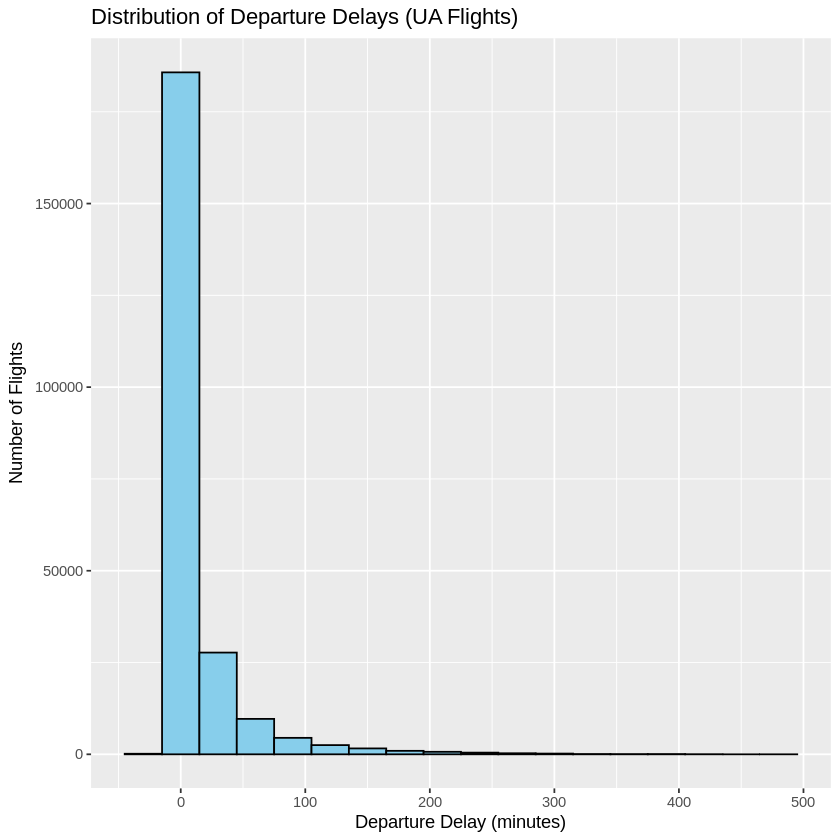

In [ ]:
ggplot(ua_combined, aes(x = departure_delay_minutes)) +
  geom_histogram(binwidth = 30, fill = "skyblue", color = "black") +
  labs(title = "Distribution of Departure Delays (UA Flights)",
       x = "Departure Delay (minutes)", y = "Number of Flights")

#### Relationship Between Time of Day and Departure Delay
**Assignee:** BB

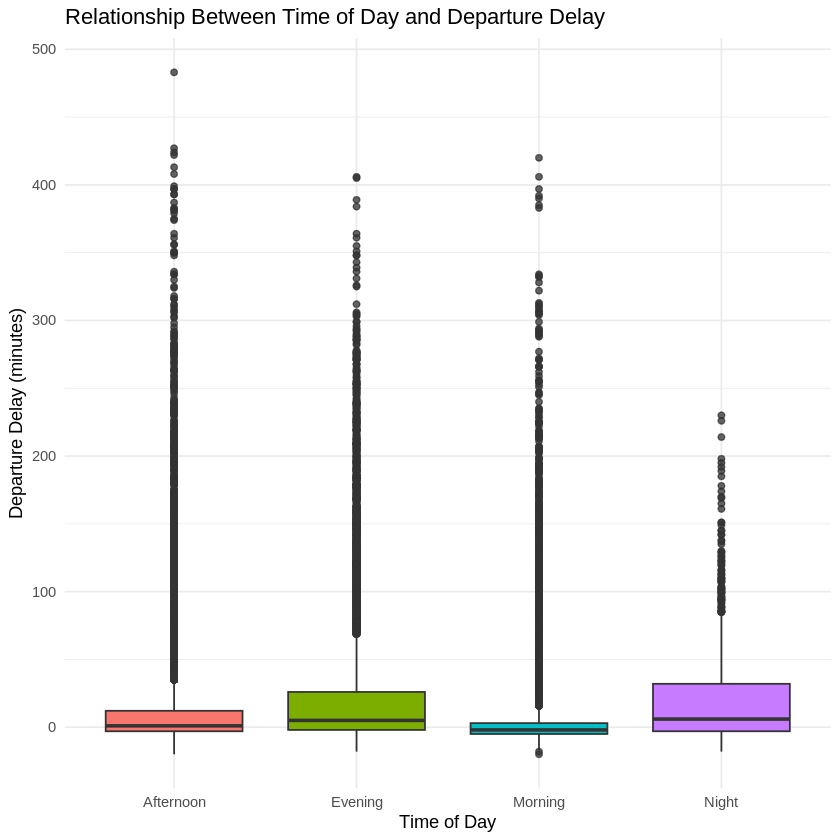

In [ ]:
ggplot(ua_combined, aes(x = time_of_day, y = departure_delay_minutes, fill = time_of_day)) +
  geom_boxplot(outlier.alpha = 0.3) +
  labs(title = "Relationship Between Time of Day and Departure Delay",
       x = "Time of Day",
       y = "Departure Delay (minutes)") +
  theme_minimal() +
  theme(legend.position = "none")


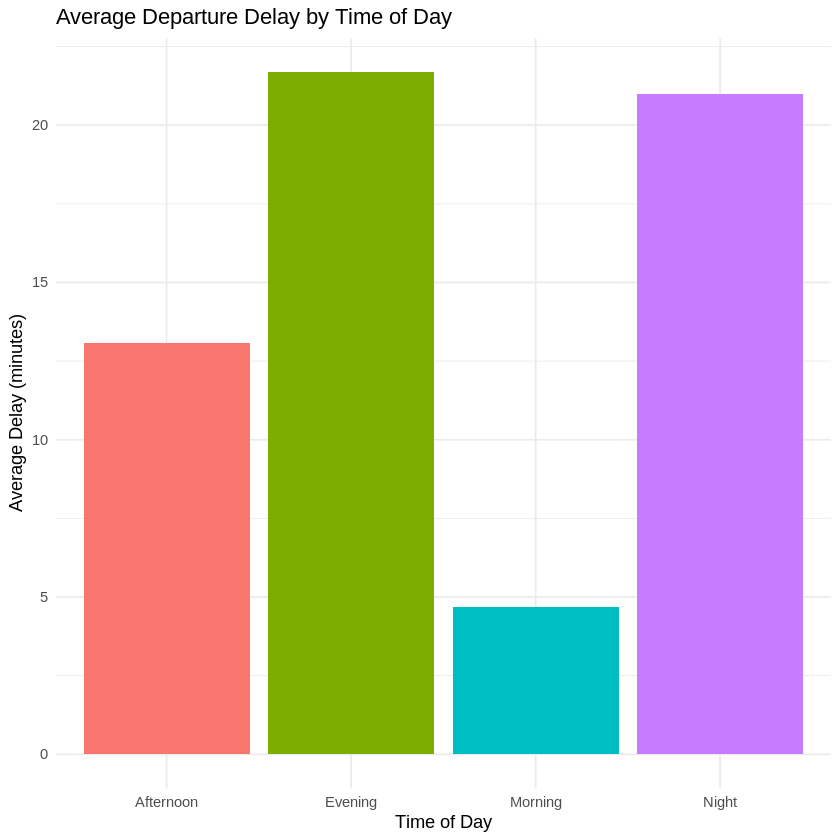

In [ ]:
ua_combined %>%
  group_by(time_of_day) %>%
  summarize(avg_delay = mean(departure_delay_minutes, na.rm = TRUE)) %>%
  ggplot(aes(x = time_of_day, y = avg_delay, fill = time_of_day)) +
  geom_col() +
  labs(title = "Average Departure Delay by Time of Day",
       x = "Time of Day",
       y = "Average Delay (minutes)") +
  theme_minimal() +
  theme(legend.position = "none")


Flights in the evening and night generally show longer delays, while morning flights tend to have shorter delays.

#### Relationship Between Time of Year and Departure Delay

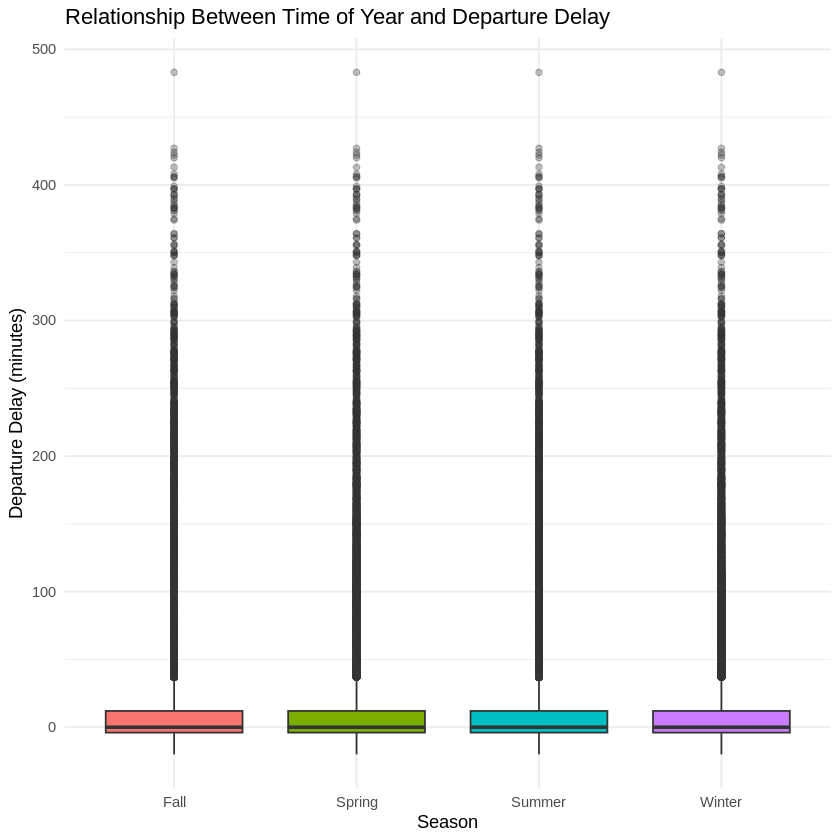

In [ ]:
ggplot(ua_combined, aes(x = time_of_year, y = departure_delay_minutes, fill = time_of_year)) +
  geom_boxplot(outlier.alpha = 0.3) +
  labs(title = "Relationship Between Time of Year and Departure Delay",
       x = "Season",
       y = "Departure Delay (minutes)") +
  theme_minimal() +
  theme(legend.position = "none")


#### Relationship Between Visibility and Departure Delay BB

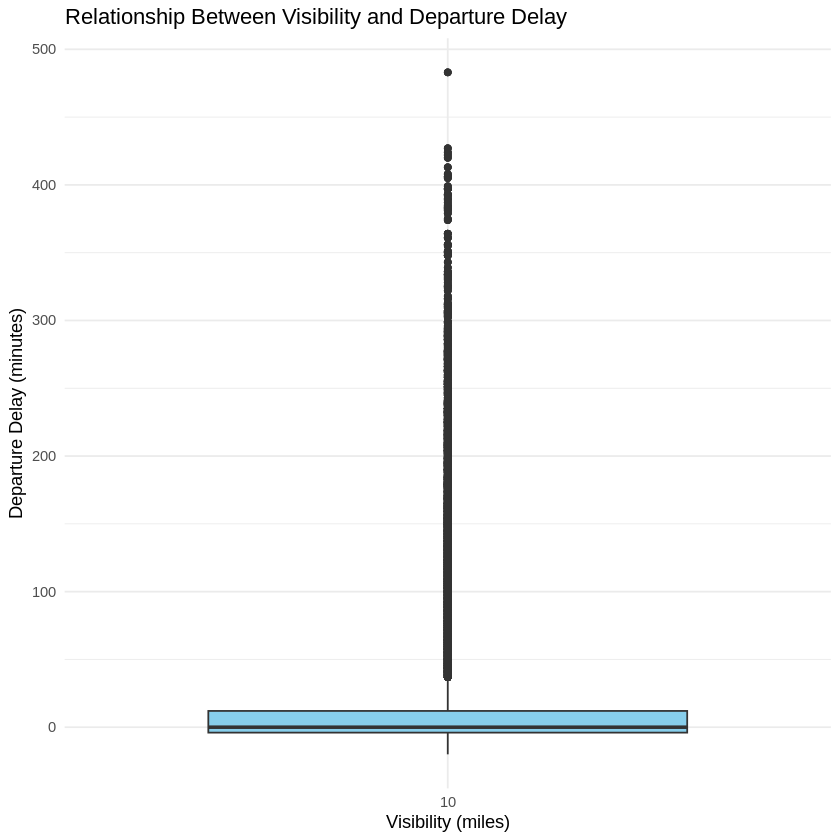

In [ ]:
ggplot(ua_combined, aes(x = as.factor(visibility), y = departure_delay_minutes)) +
  geom_boxplot(fill = "skyblue") +
  labs(title = "Relationship Between Visibility and Departure Delay",
       x = "Visibility (miles)",
       y = "Departure Delay (minutes)") +
  theme_minimal()


The boxplot demonstrates that most flights happened when visibility was around
10 miles, meaning the weather was clear. Since there are not many flights with low visibility, we don’t see much difference in delays. This means visibility doesn’t seem to have a big effect on how late the flights were.

## Exploratory Data Analysis
**Assignee:** Prince

### Relationship Between Temperature and Delay

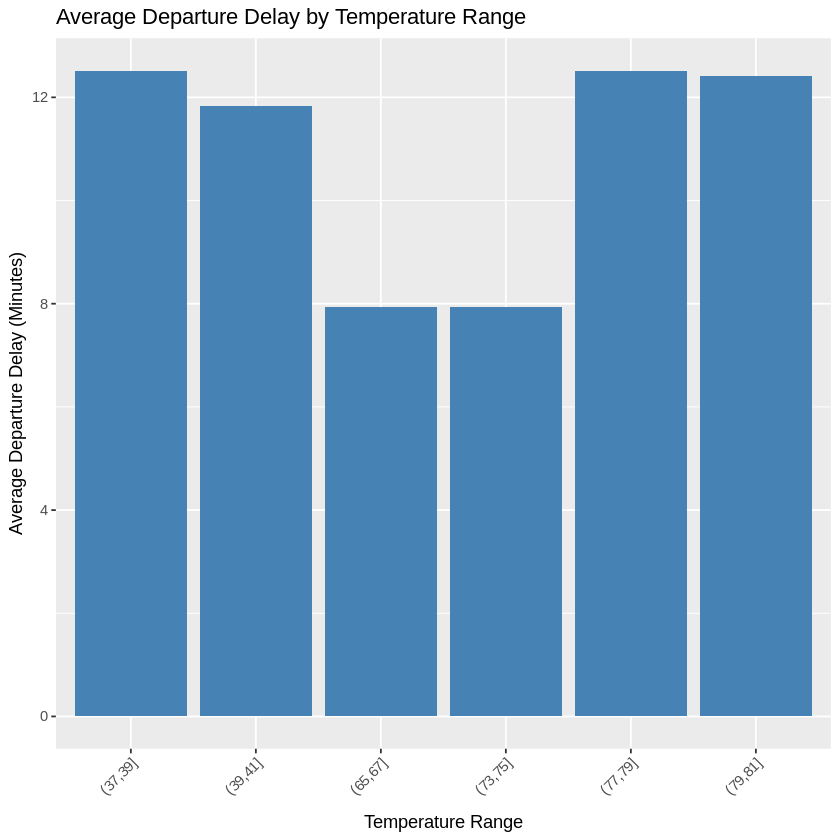

In [ ]:
temp_delay_summary <- ua_combined %>%
  mutate(temp_bin = cut(temperature, breaks = seq(floor(min(temperature)), ceiling(max(temperature)), by = 2))) %>%
  group_by(temp_bin) %>%
  summarize(avg_delay = mean(departure_delay_minutes, na.rm = TRUE)) %>%
  ungroup()

ggplot(temp_delay_summary, aes(x = temp_bin, y = avg_delay)) +
  geom_col(fill = "steelblue") +
  labs(title = "Average Departure Delay by Temperature Range",
       x = "Temperature Range",
       y = "Average Departure Delay (Minutes)") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

###Relationship between Season (time_of_year)  and Delay

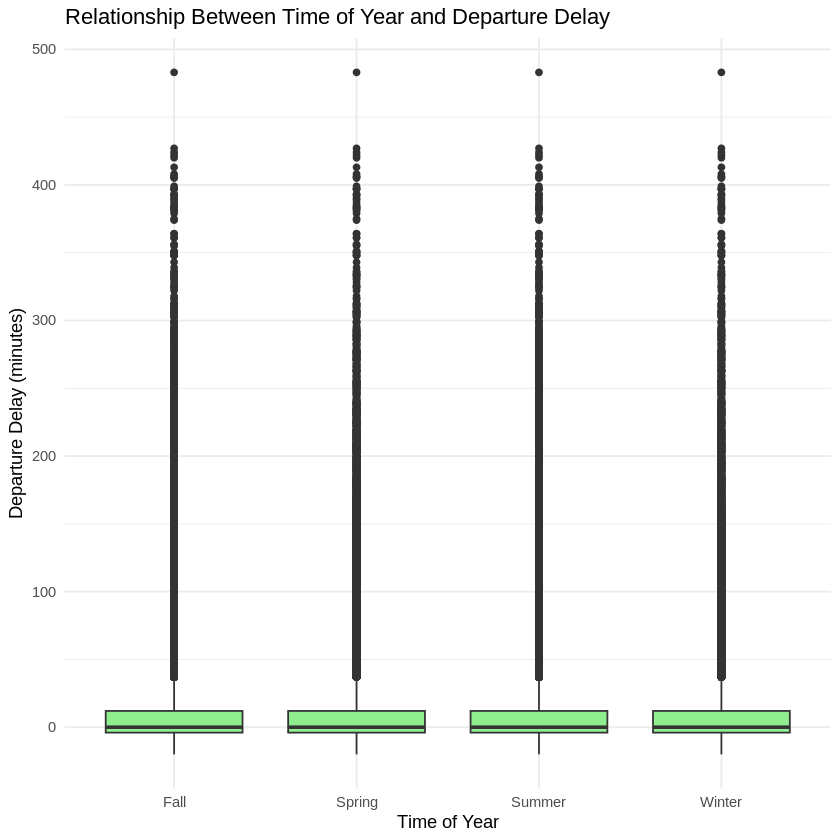

In [ ]:
ggplot(ua_combined, aes(x = as.factor(time_of_year), y = departure_delay_minutes)) +
  geom_boxplot(fill = "lightgreen") +
  labs(title = "Relationship Between Time of Year and Departure Delay",
       x = "Time of Year",
       y = "Departure Delay (minutes)") +
  theme_minimal()


### Relationship between Visibility and Delay for Each Season

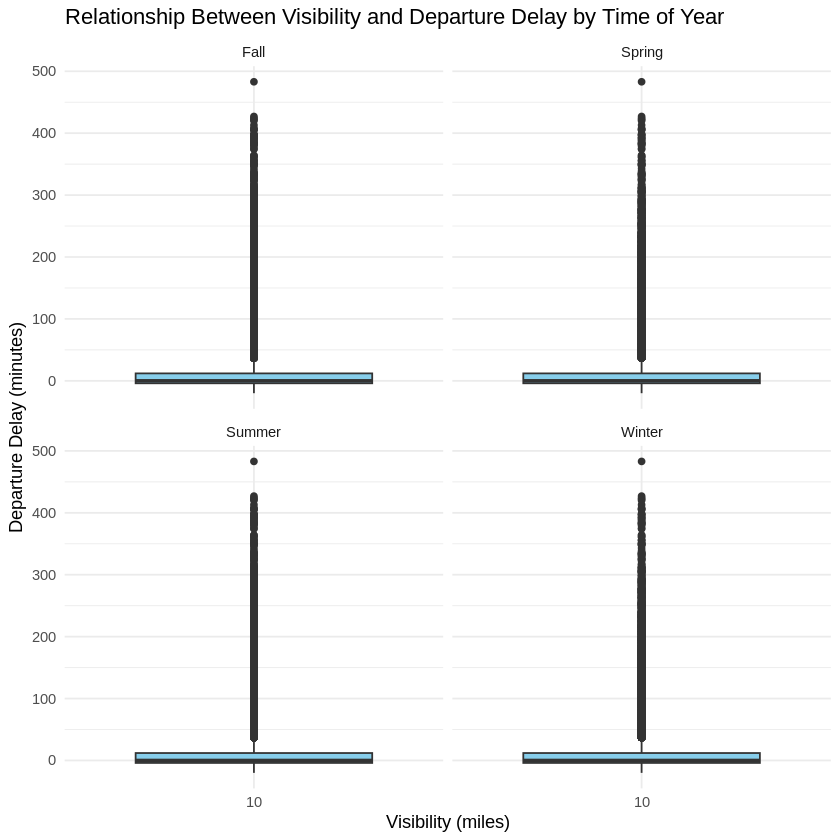

In [ ]:
ggplot(ua_combined, aes(x = as.factor(visibility), y = departure_delay_minutes)) +
  geom_boxplot(fill = "skyblue") +
  labs(title = "Relationship Between Visibility and Departure Delay by Time of Year",
       x = "Visibility (miles)",
       y = "Departure Delay (minutes)") +
  facet_wrap(~ time_of_year) +
  theme_minimal()



### Relationship between Residuals and Fitted Values (Model Performance)

`geom_smooth()` using formula = 'y ~ x'


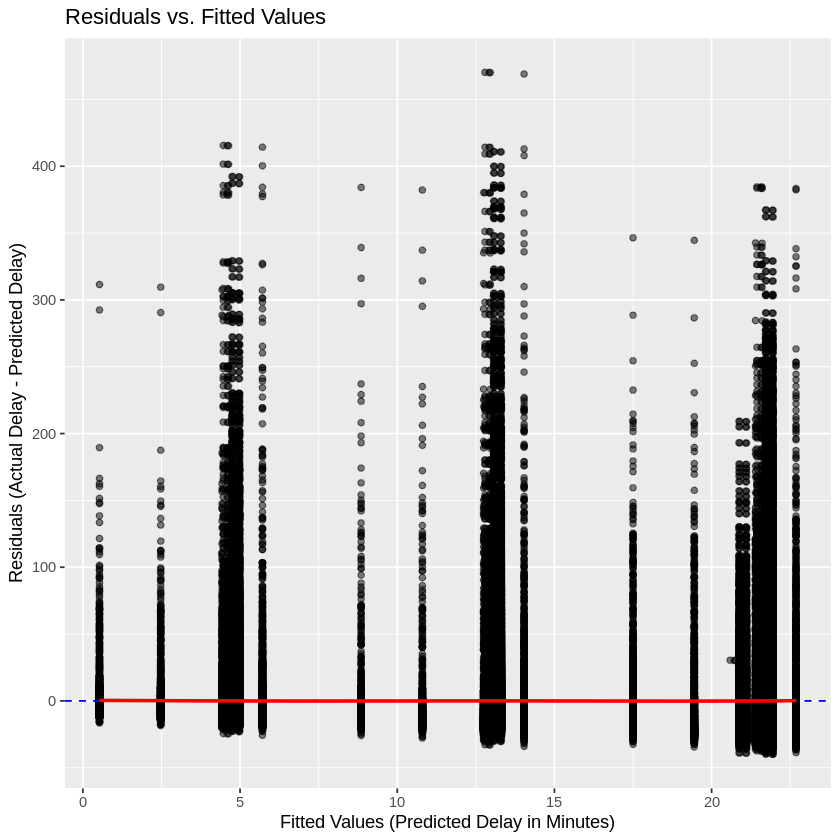

In [ ]:
# new data frame with residuals and fitted values
diag_data <- data.frame(
  Fitted_Values = fitted(model_delay),
  Residuals = residuals(model_delay)
)

# Plot for Residuals vs. Fitted Values
ggplot(diag_data, aes(x = Fitted_Values, y = Residuals)) +
  geom_point(alpha = 0.5) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "blue") +
  geom_smooth(method = "loess", color = "red", se = FALSE) + # smoothing line to see the trend
  labs(title = "Residuals vs. Fitted Values",
       x = "Fitted Values (Predicted Delay in Minutes)",
       y = "Residuals (Actual Delay - Predicted Delay)")

## Permutation Testing
**Assignee:** Alyssa

A permutation test (also called a randomization test) is a method to test whether an observed difference between variables is **statistically significant**.

It works by using the data to build a sampling distribution under the null hypothesis. **We want to test to see if what we are observing is truly accurate or just by random chance.**

### Hypothesis

We wil perform TWP permutation tests to see which variable -- `time_of_day` or `time_of_year` -- explains more variation in departure delays.

#### **Hypothesis 1**: Does `time_of_day` affect delays?

In [ ]:
# if needed to perform test
install.packages("infer")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘patchwork’




In [ ]:

library(dplyr)
library(infer)

# Filter data and ensure no missing values
ua_timeofday <- ua_combined %>%
  filter(!is.na(time_of_day), !is.na(departure_delay_minutes))

# Observed F-statistic, variation in delays (since time_of_day has >2 groups)
obs_stat_day <- ua_timeofday %>%
  specify(departure_delay_minutes ~ time_of_day) %>%
  calculate(stat = "F")

# Permutation test (randomizing time_of_day labels)
# shuffle 500 times and recalculate
set.seed(123)
perm_day <- ua_timeofday %>%
  specify(departure_delay_minutes ~ time_of_day) %>%
  hypothesize(null = "independence") %>%
  generate(reps = 500, type = "permute") %>%
  calculate(stat = "F")

# Compute p-value
p_value_day <- perm_day %>%
  get_p_value(obs_stat = obs_stat_day, direction = "greater")

p_value_day

Warning message:
“Please be cautious in reporting a p-value of 0. This result is an approximation
based on the number of `reps` chosen in the `generate()` step.
ℹ See `get_p_value()` (`?infer::get_p_value()`) for more information.”


p_value
<dbl>
0


This ouput is a good sign!

This tested the actual F-statistic for our  original data — aka how much variation in delays can be explained by differences in `time_of_day`.

We then shuffled the `time_of_day` labels 500 times and recalculated that same statistic each time. This built a null distribution of “random” differences — what we would expect if time of day didnt matter at all.

    p-value = 0

This p-value is less than 0.002 (1/500 = 0.002), thus indicating a large statistical significance for this variable. The closer to zero, the more significant.

**This means that the observed differences in delays across morning, afternoon, evening, and night flights are very unlikely to be due to random chance.**

#### **Hypothesis 2**: Does `time_of_year` affect delays?

In [ ]:
# Filter for complete data
ua_timeofyear <- ua_combined %>%
  filter(!is.na(time_of_year), !is.na(departure_delay_minutes))

# Observed F-statistic
obs_stat_year <- ua_timeofyear %>%
  specify(departure_delay_minutes ~ time_of_year) %>%
  calculate(stat = "F")

# Permutation test (randomizing time_of_year labels)
set.seed(123)
perm_year <- ua_timeofyear %>%
  specify(departure_delay_minutes ~ time_of_year) %>%
  hypothesize(null = "independence") %>%
  generate(reps = 500, type = "permute") %>%
  calculate(stat = "F")

# Compute p-value
p_value_year <- perm_year %>%
  get_p_value(obs_stat = obs_stat_year, direction = "greater")

p_value_year

p_value
<dbl>
1


Following the same observations as above...

This tested the actual F-statistic for our original data — aka how much variation in delays can be explained by differences in `time_of_year`.

We then shuffled the `time_of_year` labels 500 times and recalculated that same statistic each time. This built a null distribution of “random” differences — what we would expect if time of year didnt matter at all.

    p-value = 1

This indicates that there is **no statistically significant relationship** between the season and the average departure delay for United Airlines flights.
The observed differences between Winter, Spring, Summer, and Fall were consistent with **what could occur by random variation.**

### Visuals

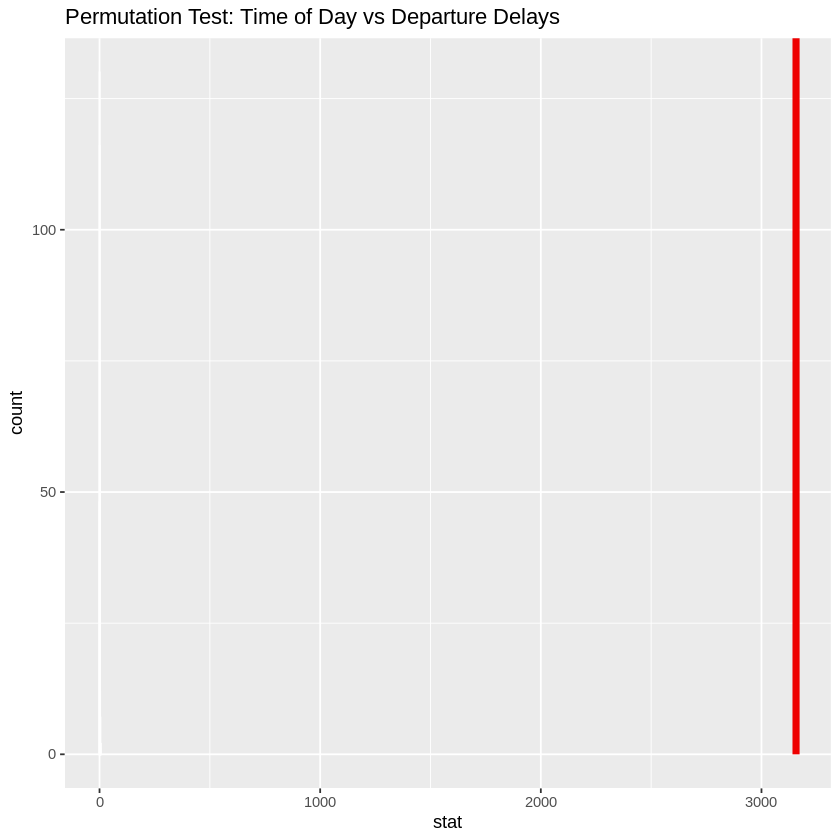

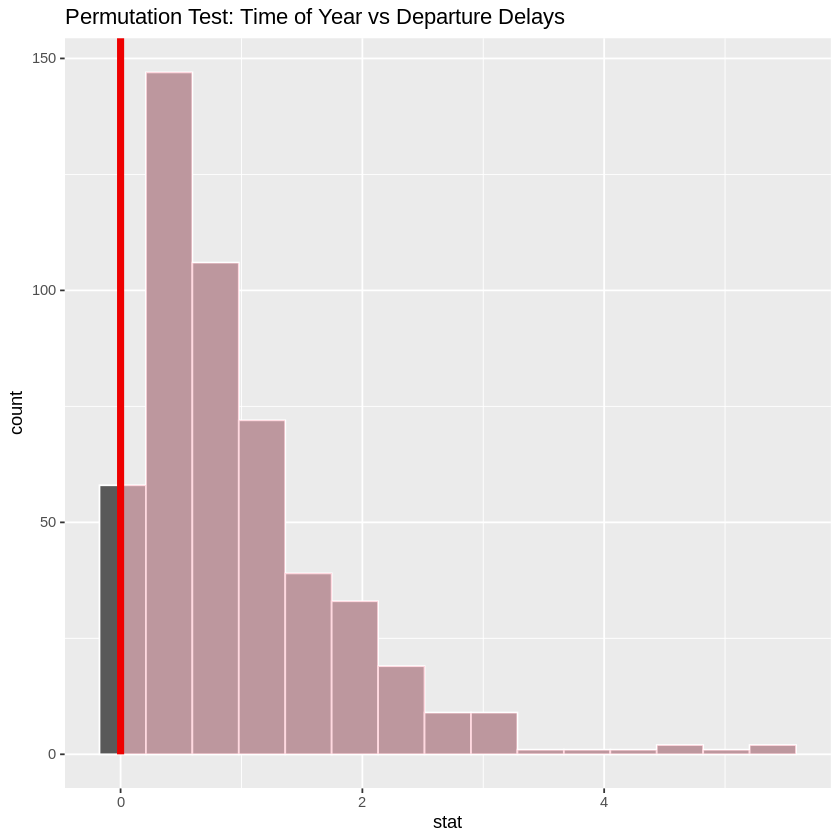

In [ ]:
# Time of day visualization
visualize(perm_day) +
  shade_p_value(obs_stat = obs_stat_day, direction = "greater") +
  ggtitle("Permutation Test: Time of Day vs Departure Delays")

# Time of year visualization
visualize(perm_year) +
  shade_p_value(obs_stat = obs_stat_year, direction = "greater") +
  ggtitle("Permutation Test: Time of Year vs Departure Delays")


### Summary

The visuals confirm a descrptive obersvation of our p-values above...

**Graph 1**:

Shows `time_of_day` versus departure delays. The red line (F-stat) if way off to the right, which means that none of the shuffled data produced a large effect.

**Graph 2:**

Shows the `time_of_year` versus departure delays. The red line(F-stat) sits inside the main body of the histogram... meaning that there were many randomized results that were extreme/just as extreme as the real one.

AKA... there is no evidence to support that departure delays have a meaningful difference, and thus could be by random chance.

## Conclusion

**Domain Problem:**

Which of the 6 variables has the biggest effect on departure delay times for United Airlines?

**Suggested Solution:**

Time of day